# 01 - Exploratory Data Analysis

1. Dataset overview - size, columns, data types, missing values
2. Anomaly distribution - event count, lengths, temporal spread
3. Signal visualisation - raw sensor channels with anomaly windows
4. Channel statistics - which channels separate normal from anomaly most clearly
5. Train vs test shift - why distributions differ and what that means for threshold transfer

### Summary Table

| Metric | Value |
|---|---|
| Train rows | 14,728,321 |
| Test rows | 521,280 |
| Scored channels | 58 |
| Anomaly events (train total) | 190 |
| Anomaly events (val split) | 38 |
| Anomaly rate | 10.48% |
| Shortest event | 1 sample |
| Longest event | 116,061 samples |
| Event length median | 602 samples |
| Missing values | 0 |
| Mean KS distance (train vs test) | 0.43 |
| Max KS distance | 0.97 (channel_15) |
| Highest telecommand lift | ~9.5× (telecommand_352 / 353 / 354) |

---
## 0 - Imports

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

from sentinel.ml_logic.data import (
    load_train, load_test, load_target_channels,
    find_anomaly_segments, get_channel_cols, get_telecommand_cols
)
from sentinel.ml_logic.metrics import corrected_event_f05
from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

---
## 1 - Data Overview
- Train has **14.7 M rows × 89 columns** - a substantial 14-year time series.
- Test has **521 K rows** - roughly 1 additional year.
- IDs are contiguous integers; train and test are sequential (no overlap).
- **No missing values** anywhere in the dataset.
- 76 sensor **channels** (float32) + 11 **telecommand** flags (sparse binary float64).
- Telecommand columns are nearly always 0 - they represent rare commanded events.

In [48]:
train = load_train()
test  = load_test()
target_channels = load_target_channels()

channel_cols     = get_channel_cols(train)
telecommand_cols = get_telecommand_cols(train)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Channel cols       : {len(channel_cols)}')
print(f'Telecommand cols   : {len(telecommand_cols)}')
print(f'Target channels    : {len(target_channels)}')
print(f'Train ID range     : {train["id"].min():,} → {train["id"].max():,}')
print(f'Test  ID range     : {test["id"].min():,} → {test["id"].max():,}')

Train shape : (14728321, 89)
Test shape  : (521280, 88)
Channel cols       : 76
Telecommand cols   : 11
Target channels    : 58
Train ID range     : 0 → 14,728,320
Test  ID range     : 14,728,321 → 15,249,600


In [49]:
train

,id,channel_1,channel_10,channel_11,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,...,telecommand_351,telecommand_352,telecommand_353,telecommand_354,telecommand_36,telecommand_376,telecommand_38,telecommand_39,telecommand_40,is_anomaly
0,0,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,3,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,4,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14728316,14728316,0.13791,0.0,0.0,0.218915,0.270384,0.631070,0.313122,0.786995,0.266552,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
14728317,14728317,0.13791,0.0,0.0,0.218915,0.268824,0.631070,0.314563,0.785157,0.266552,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
14728318,14728318,0.13791,0.0,0.0,0.218915,0.268824,0.631070,0.314563,0.785157,0.266552,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
14728319,14728319,0.13791,0.0,0.0,0.218915,0.268824,0.631070,0.314563,0.785157,0.266552,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [50]:
print('--- Column dtypes ---')
print(train.dtypes.value_counts())

--- Column dtypes ---
float32    76
float64    11
int64       1
uint8       1
Name: count, dtype: int64


In [51]:
# Missing values
nulls = train.isnull().sum()
print(f'Columns with any NaN: {(nulls > 0).sum()}')
if (nulls > 0).any():
    print(nulls[nulls > 0])
else:
    print('No missing values - dataset is complete.')

Columns with any NaN: 0
No missing values - dataset is complete.


In [52]:
# Basic statistics for channel columns
print('--- Descriptive statistics (channel columns) ---')
train[channel_cols].describe().T.round(4)

--- Descriptive statistics (channel columns) ---


,count,mean,std,min,25%,50%,75%,max
channel_1,14728321.0,0.1380,0.0044,0.0922,0.1379,0.1379,0.1379,0.4332
channel_2,14728321.0,0.1267,0.0113,0.0000,0.1263,0.1263,0.1263,0.9999
channel_3,14728321.0,0.1267,0.0123,0.0000,0.1263,0.1263,0.1263,0.9999
channel_4,14728321.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0900
channel_5,14728321.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0842
...,...,...,...,...,...,...,...,...
channel_72,14728321.0,0.8240,0.0086,0.0000,0.8205,0.8232,0.8278,0.8392
channel_73,14728321.0,0.9377,0.0105,0.0000,0.9339,0.9376,0.9417,0.9540
channel_74,14728321.0,0.9839,0.0106,0.0000,0.9809,0.9836,0.9868,1.0000
channel_75,14728321.0,0.9097,0.0088,0.0000,0.9075,0.9093,0.9121,0.9235


In [53]:
# Telecommand columns - sparse binary flags
print('--- Telecommand columns: mean activation rate ---')
train[telecommand_cols].mean().sort_values(ascending=False).to_frame('mean_activation')

--- Telecommand columns: mean activation rate ---


,mean_activation
telecommand_36,4.481163e-06
telecommand_350,3.802198e-06
telecommand_376,3.123234e-06
telecommand_39,2.580063e-06
telecommand_40,2.580063e-06
telecommand_38,2.376374e-06
telecommand_353,1.901099e-06
telecommand_354,1.901099e-06
telecommand_352,1.765306e-06
telecommand_351,1.629514e-06


---
## 2 - Anomaly Distribution
- Anomaly prevalence is ~**10.5%** by sample.
- There are **190 anomaly events** (contiguous segments).
- Segment lengths span a massive range: from **1 sample** (point anomaly) to **116,061 samples** (sustained fault). The distribution is strongly right-skewed.
- Anomalies are **spread across the full time range** with some clustering - not purely isolated in one mission phase.
- Predicting all-zeros yields **F0.5 = 0.0** (recall = 0), confirming the metric requires actual detections.

### Class balance visualization

In [54]:
n_total   = len(train)
n_anomaly = int(train['is_anomaly'].sum())
n_nominal = n_total - n_anomaly

print(f'Total samples  : {n_total:>12,}')
print(f'Nominal        : {n_nominal:>12,}  ({n_nominal/n_total*100:.2f}%)')
print(f'Anomaly        : {n_anomaly:>12,}  ({n_anomaly/n_total*100:.2f}%)')

Total samples  :   14,728,321
Nominal        :   13,184,217  (89.52%)
Anomaly        :    1,544,104  (10.48%)


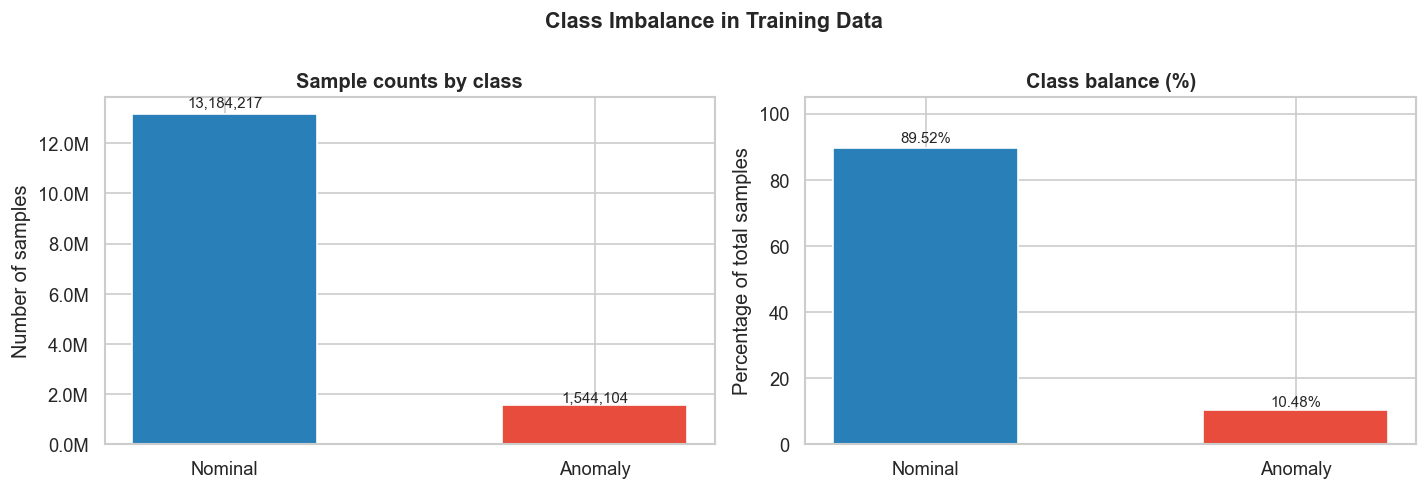

In [55]:
# Class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = pd.Series({'Nominal': n_nominal, 'Anomaly': n_anomaly})
colors = [NOMINAL_COLOR, ANOMALY_COLOR]

# Absolute counts
ax = axes[0]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
ax.set_title('Sample counts by class', fontweight='bold')
ax.set_ylabel('Number of samples')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

# Percentage
ax2 = axes[1]
pcts = pd.Series({'Nominal': n_nominal/n_total*100, 'Anomaly': n_anomaly/n_total*100})
bars2 = ax2.bar(pcts.index, pcts.values, color=colors, edgecolor='white', width=0.5)
ax2.set_title('Class balance (%)', fontweight='bold')
ax2.set_ylabel('Percentage of total samples')
ax2.set_ylim(0, 105)
for bar, val in zip(bars2, pcts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Class Imbalance in Training Data', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### Anomaly Segments

In [56]:
# Find anomaly segments
segments = find_anomaly_segments(train['is_anomaly']) # fn from ml_logic/data.py
seg_df = pd.DataFrame(segments)

print(f'Total anomaly segments (events): {len(segments)}')
print(f'Min segment length  : {seg_df["length"].min():,}')
print(f'Max segment length  : {seg_df["length"].max():,}')
print(f'Mean segment length : {seg_df["length"].mean():,.1f}')
print(f'Median segment length: {seg_df["length"].median():,.0f}')
seg_df.head(10)

Total anomaly segments (events): 190
Min segment length  : 1
Max segment length  : 116,061
Mean segment length : 8,126.9
Median segment length: 602


,start,end,length
0,115383,155649,40267
1,161604,161614,11
2,165175,165855,681
3,194565,194575,11
4,225361,263520,38160
5,327272,333647,6376
6,339469,340149,681
7,429016,429035,20
8,437161,437179,19
9,489940,489958,19


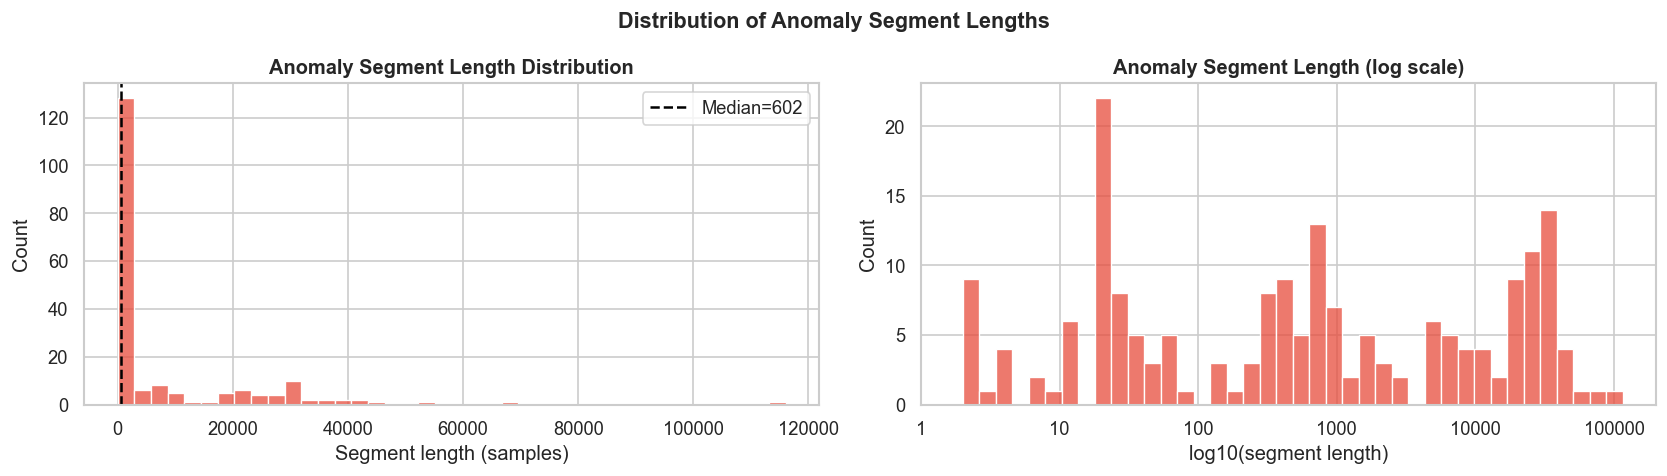

In [57]:
# Segment length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
sns.histplot(seg_df['length'], bins=40, ax=ax, color=ANOMALY_COLOR, edgecolor='white')
ax.set_xlabel('Segment length (samples)')
ax.set_ylabel('Count')
ax.set_title('Anomaly Segment Length Distribution', fontweight='bold')
ax.axvline(seg_df['length'].median(), color='black', ls='--', lw=1.5, label=f'Median={seg_df["length"].median():.0f}')
ax.legend()

ax2 = axes[1]
sns.histplot(np.log10(seg_df['length']+1), bins=40, ax=ax2, color=ANOMALY_COLOR, edgecolor='white')
ax2.set_xlabel('log10(segment length)')
ax2.set_ylabel('Count')
ax2.set_title('Anomaly Segment Length (log scale)', fontweight='bold')
ticks = [1, 10, 100, 1000, 10000, 100000]
ax2.set_xticks(np.log10(ticks))
ax2.set_xticklabels([str(t) for t in ticks])

fig.suptitle('Distribution of Anomaly Segment Lengths', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

### Temporal distribution of anomaly events

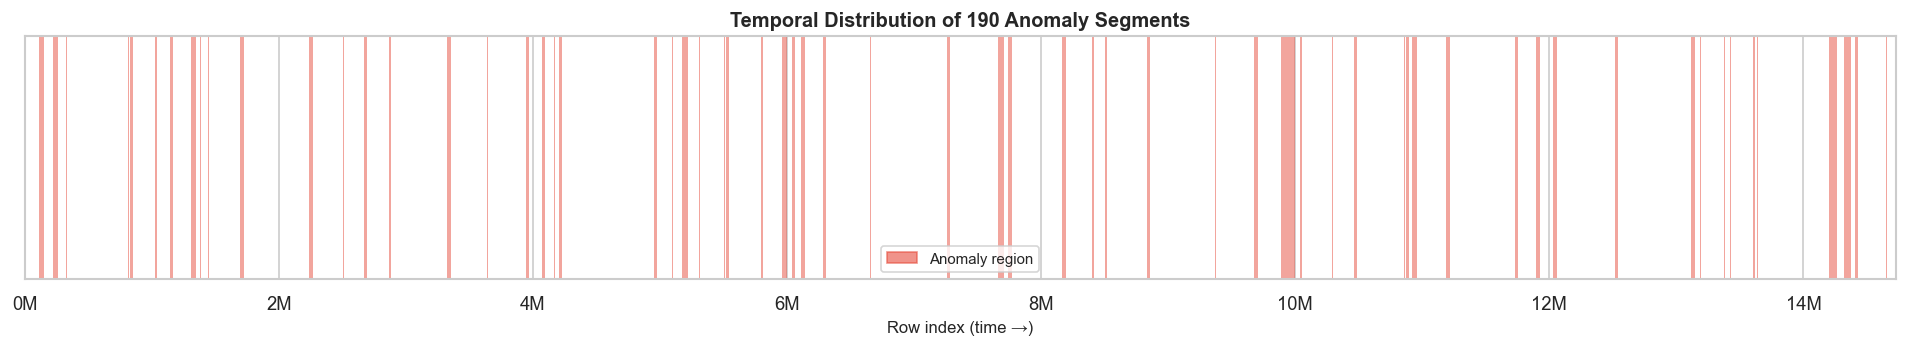

In [58]:
# Temporal distribution of anomaly events
fig, ax = plt.subplots(figsize=(16, 3))

# Background: thin shaded stripe for each anomaly segment
for seg in segments:
    ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.5, linewidth=0)

ax.set_xlim(0, n_total)
ax.set_ylim(0, 1)
ax.set_xlabel('Row index (time →)', fontsize=10)
ax.set_title(f'Temporal Distribution of {len(segments)} Anomaly Segments', fontweight='bold', fontsize=12)
ax.set_yticks([])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
anom_patch = mpatches.Patch(color=ANOMALY_COLOR, alpha=0.6, label='Anomaly region')
ax.legend(handles=[anom_patch], fontsize=9)
plt.tight_layout()
plt.show()

---
## 3 - Time Series
- Some anomaly events produce **clear, visible deviations** (spikes, level shifts) in certain channels.
- Short events (length 1–few samples) may be near-invisible - the signal barely deviates.
- Long events often show sustained level shifts or elevated noise, identifiable visually.
- Not all channels respond equally to each anomaly - indicates the fault type matters.

### Full Time Range Overview

In [59]:
# Pick a representative subset of channels for overview plots
# Use target_channels first 12 for compactness, then sample others
# OVERVIEW_CHANNELS = target_channels[:12]

# Channel 41-46
OVERVIEW_CHANNELS = [f'channel_{i}' for i in range(41, 47)]

# Top 6 by Cohen's d (mean shift):
# OVERVIEW_CHANNELS = ['channel_16', 'channel_32', 'channel_40', 'channel_24', 'channel_33', 'channel_59']

print(f'Plotting channels: {OVERVIEW_CHANNELS}')

Plotting channels: ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']


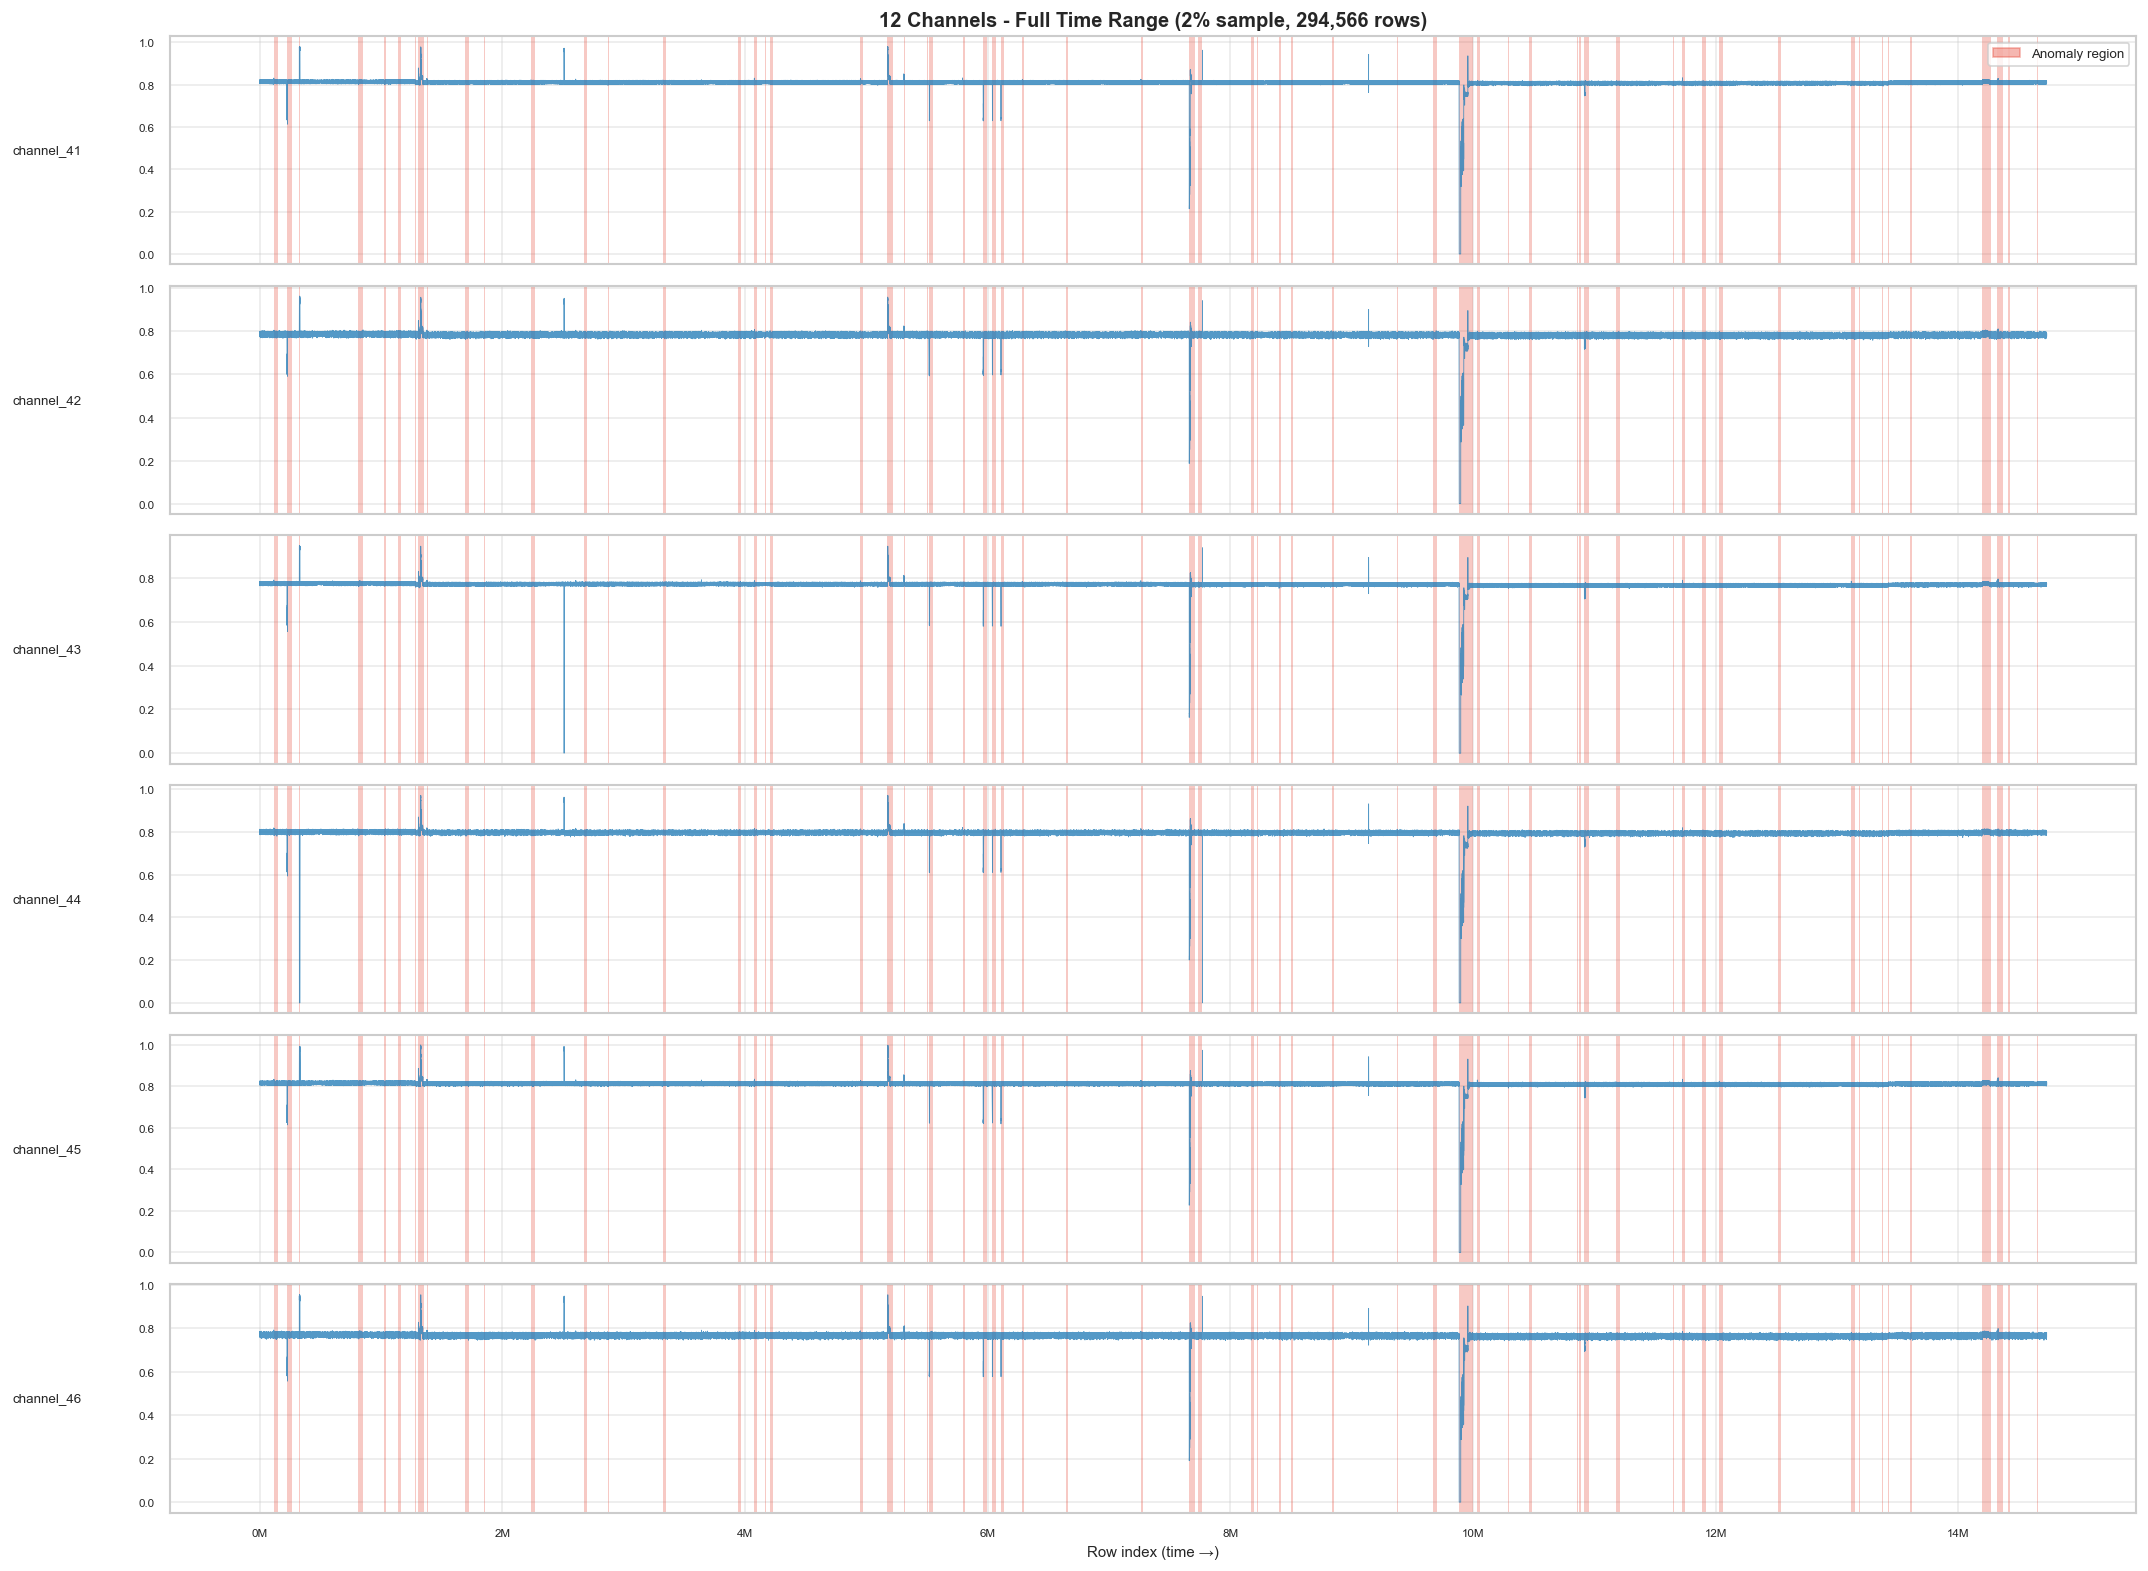

In [60]:
# Full time range overview - downsampled for display
SAMPLE_FRAC = 0.02   # 2% ≈ 295k rows - enough to see the shape
train_s = train.sample(frac=SAMPLE_FRAC, random_state=42).sort_index()

n_ch = len(OVERVIEW_CHANNELS)
fig, axes = plt.subplots(n_ch, 1, figsize=(18, 2.2 * n_ch), sharex=True)

for ax, ch in zip(axes, OVERVIEW_CHANNELS):
    ax.plot(train_s.index, train_s[ch].values, lw=0.5, color=NOMINAL_COLOR, alpha=0.8)
    # shade anomaly regions
    in_anom = False
    start_i = None
    idx_arr = train_s.index.values
    lab_arr = train_s['is_anomaly'].values
    for i, (ix, v) in enumerate(zip(idx_arr, lab_arr)):
        if v == 1 and not in_anom:
            start_i = ix
            in_anom = True
        elif v == 0 and in_anom:
            ax.axvspan(start_i, ix, color=ANOMALY_COLOR, alpha=0.3, linewidth=0)
            in_anom = False
    if in_anom:
        ax.axvspan(start_i, idx_arr[-1], color=ANOMALY_COLOR, alpha=0.3, linewidth=0)
    ax.set_ylabel(ch, fontsize=8, rotation=0, labelpad=55, va='center')
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.4)

axes[0].set_title(
    f'12 Channels - Full Time Range (2% sample, {len(train_s):,} rows)',
    fontsize=12, fontweight='bold'
)
axes[-1].set_xlabel('Row index (time →)', fontsize=9)
axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

anom_patch = mpatches.Patch(color=ANOMALY_COLOR, alpha=0.4, label='Anomaly region')
axes[0].legend(handles=[anom_patch], fontsize=8, loc='upper right')
fig.tight_layout()
plt.show()

### Zoom into 5 specific anomaly events across different length ranges

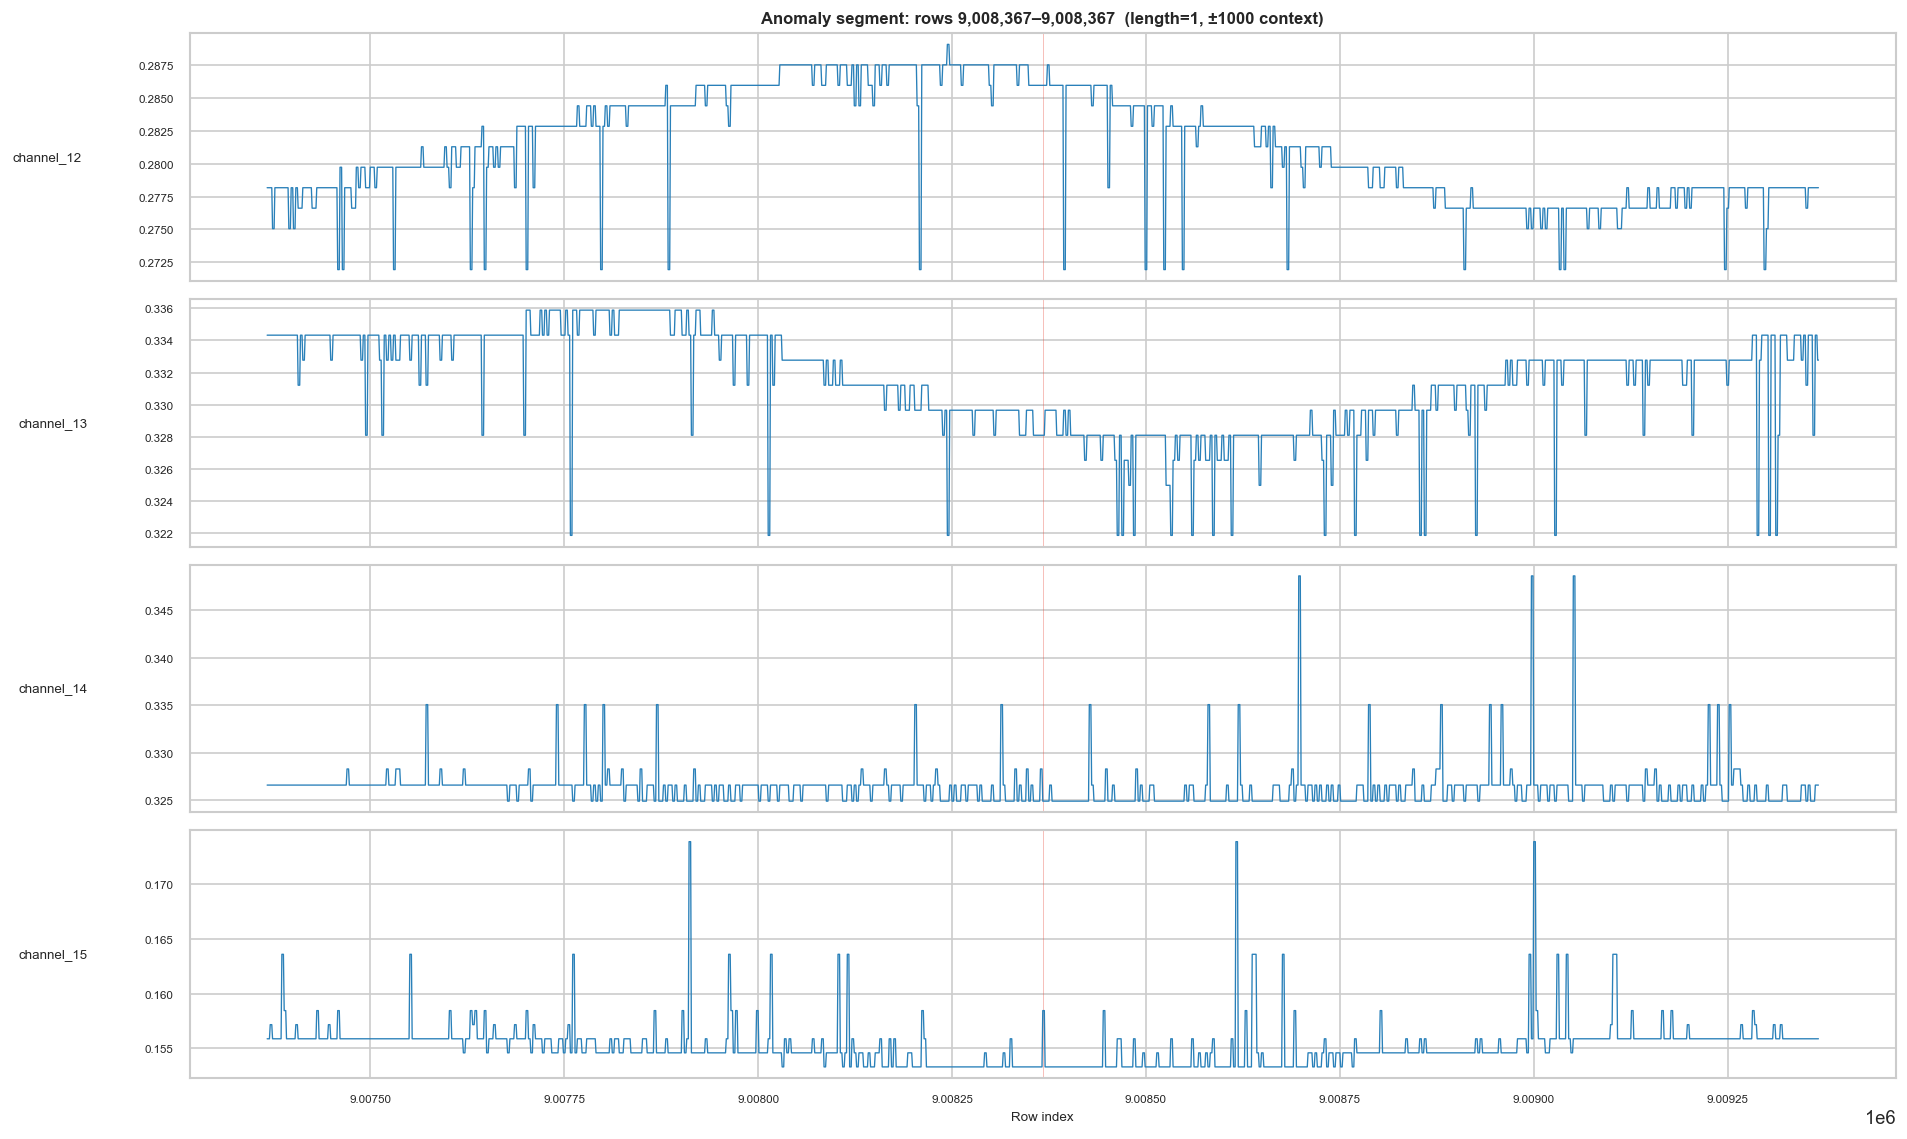

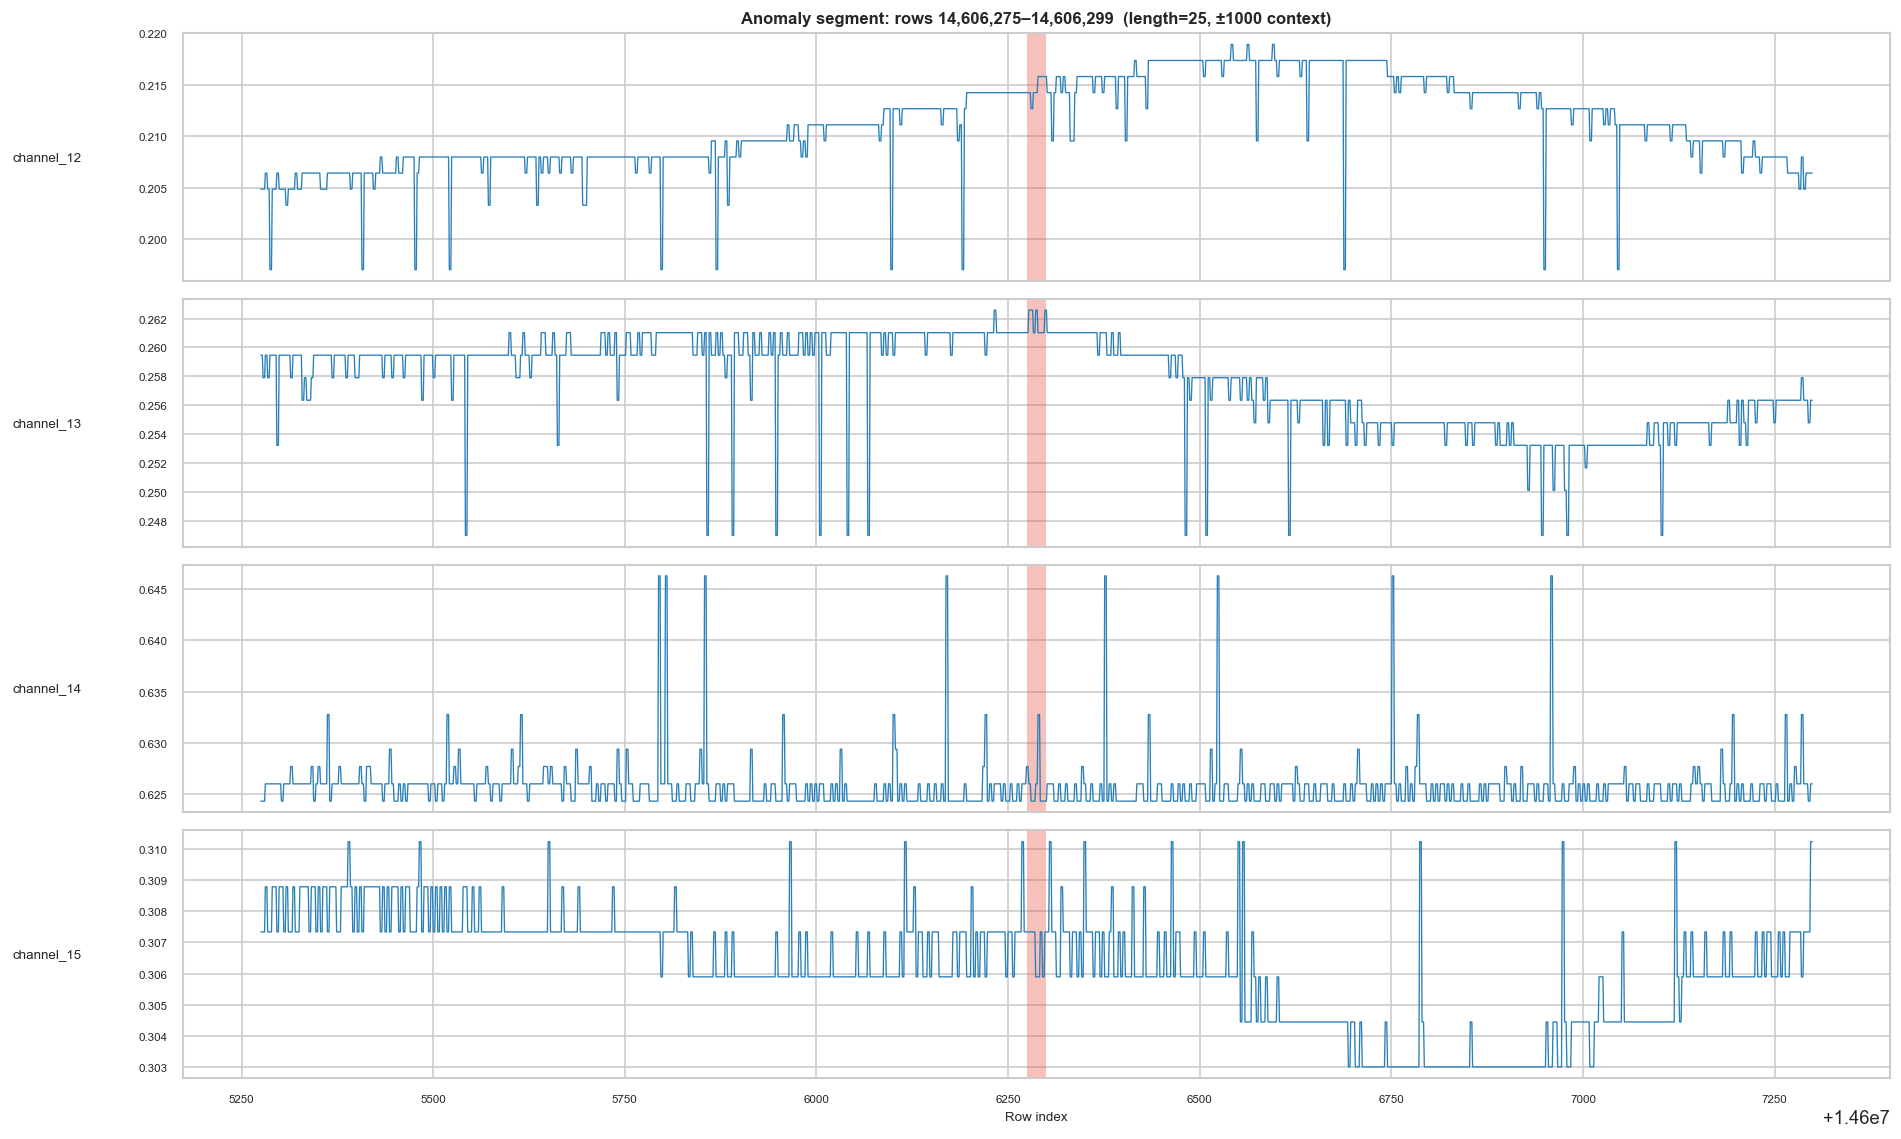

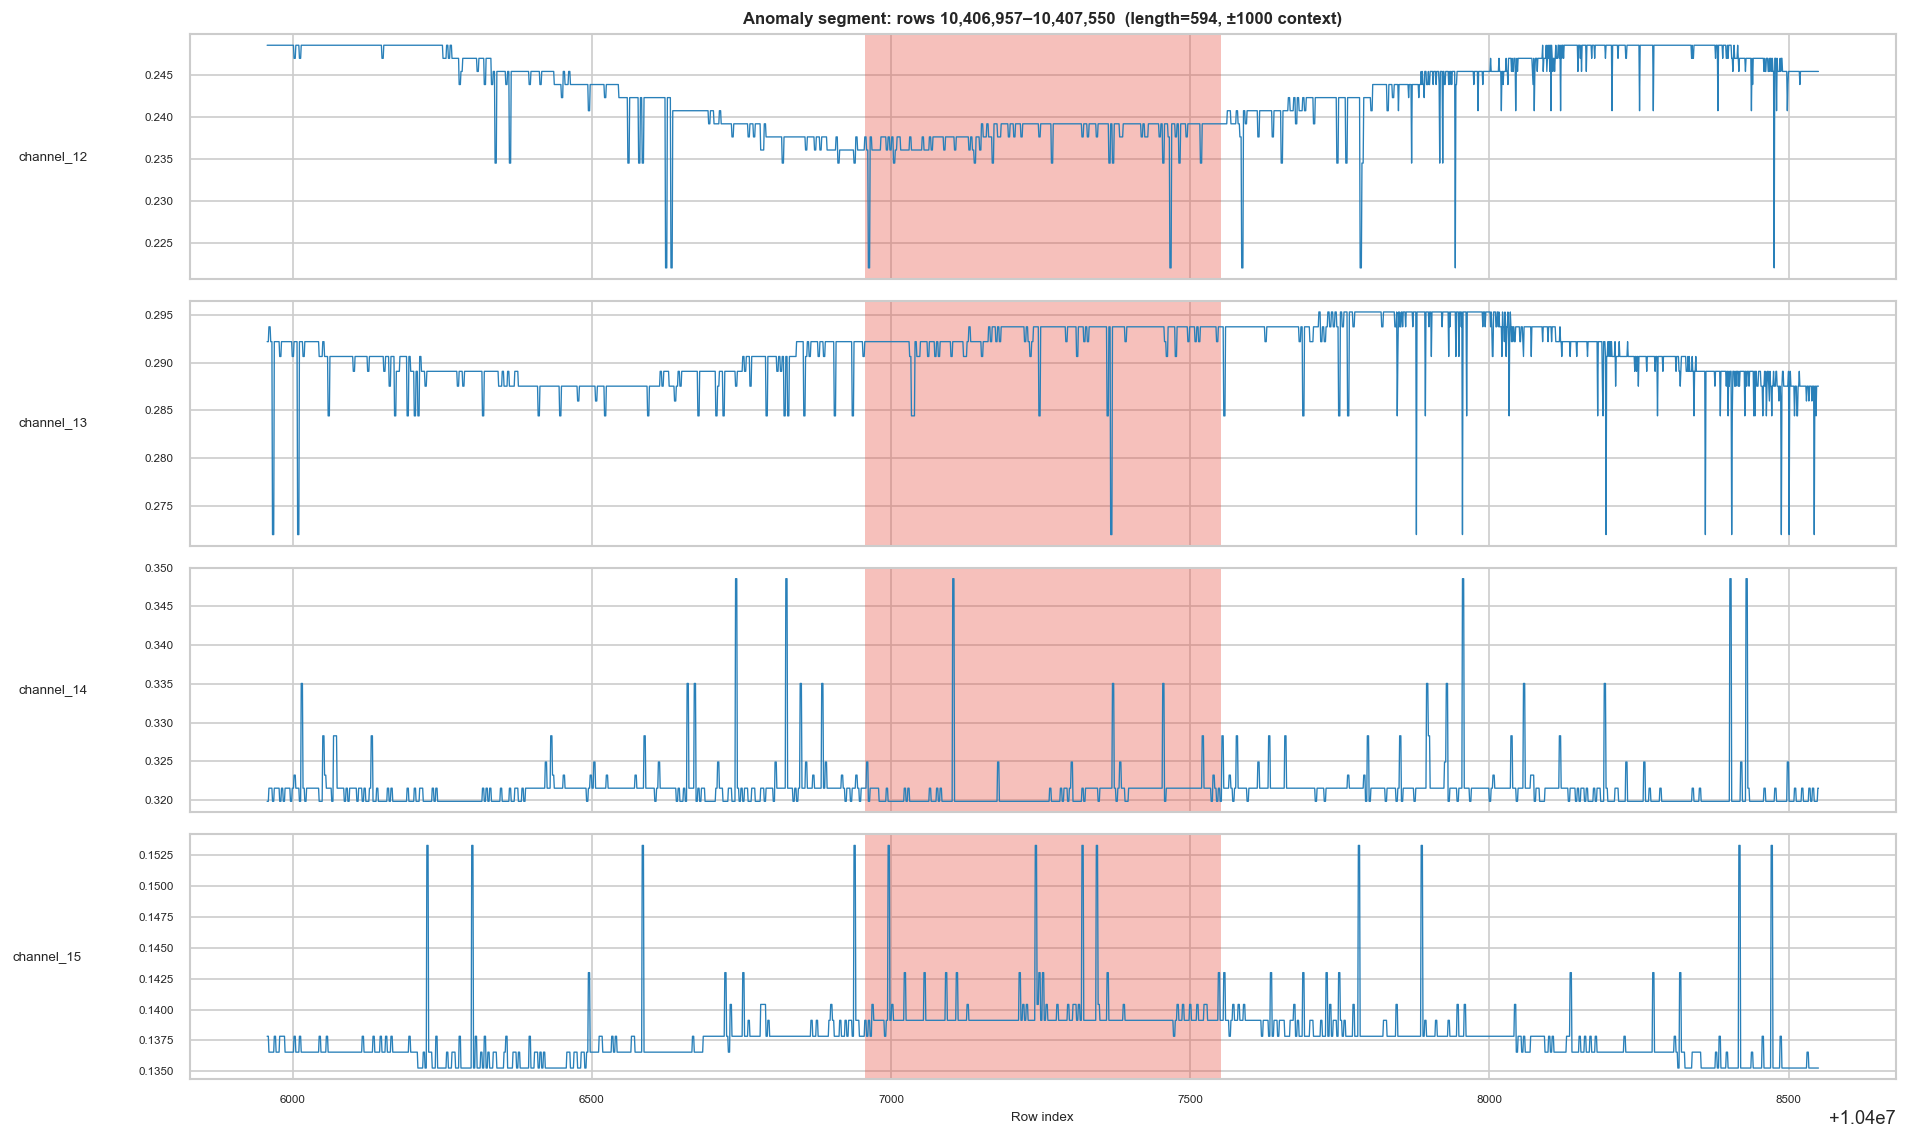

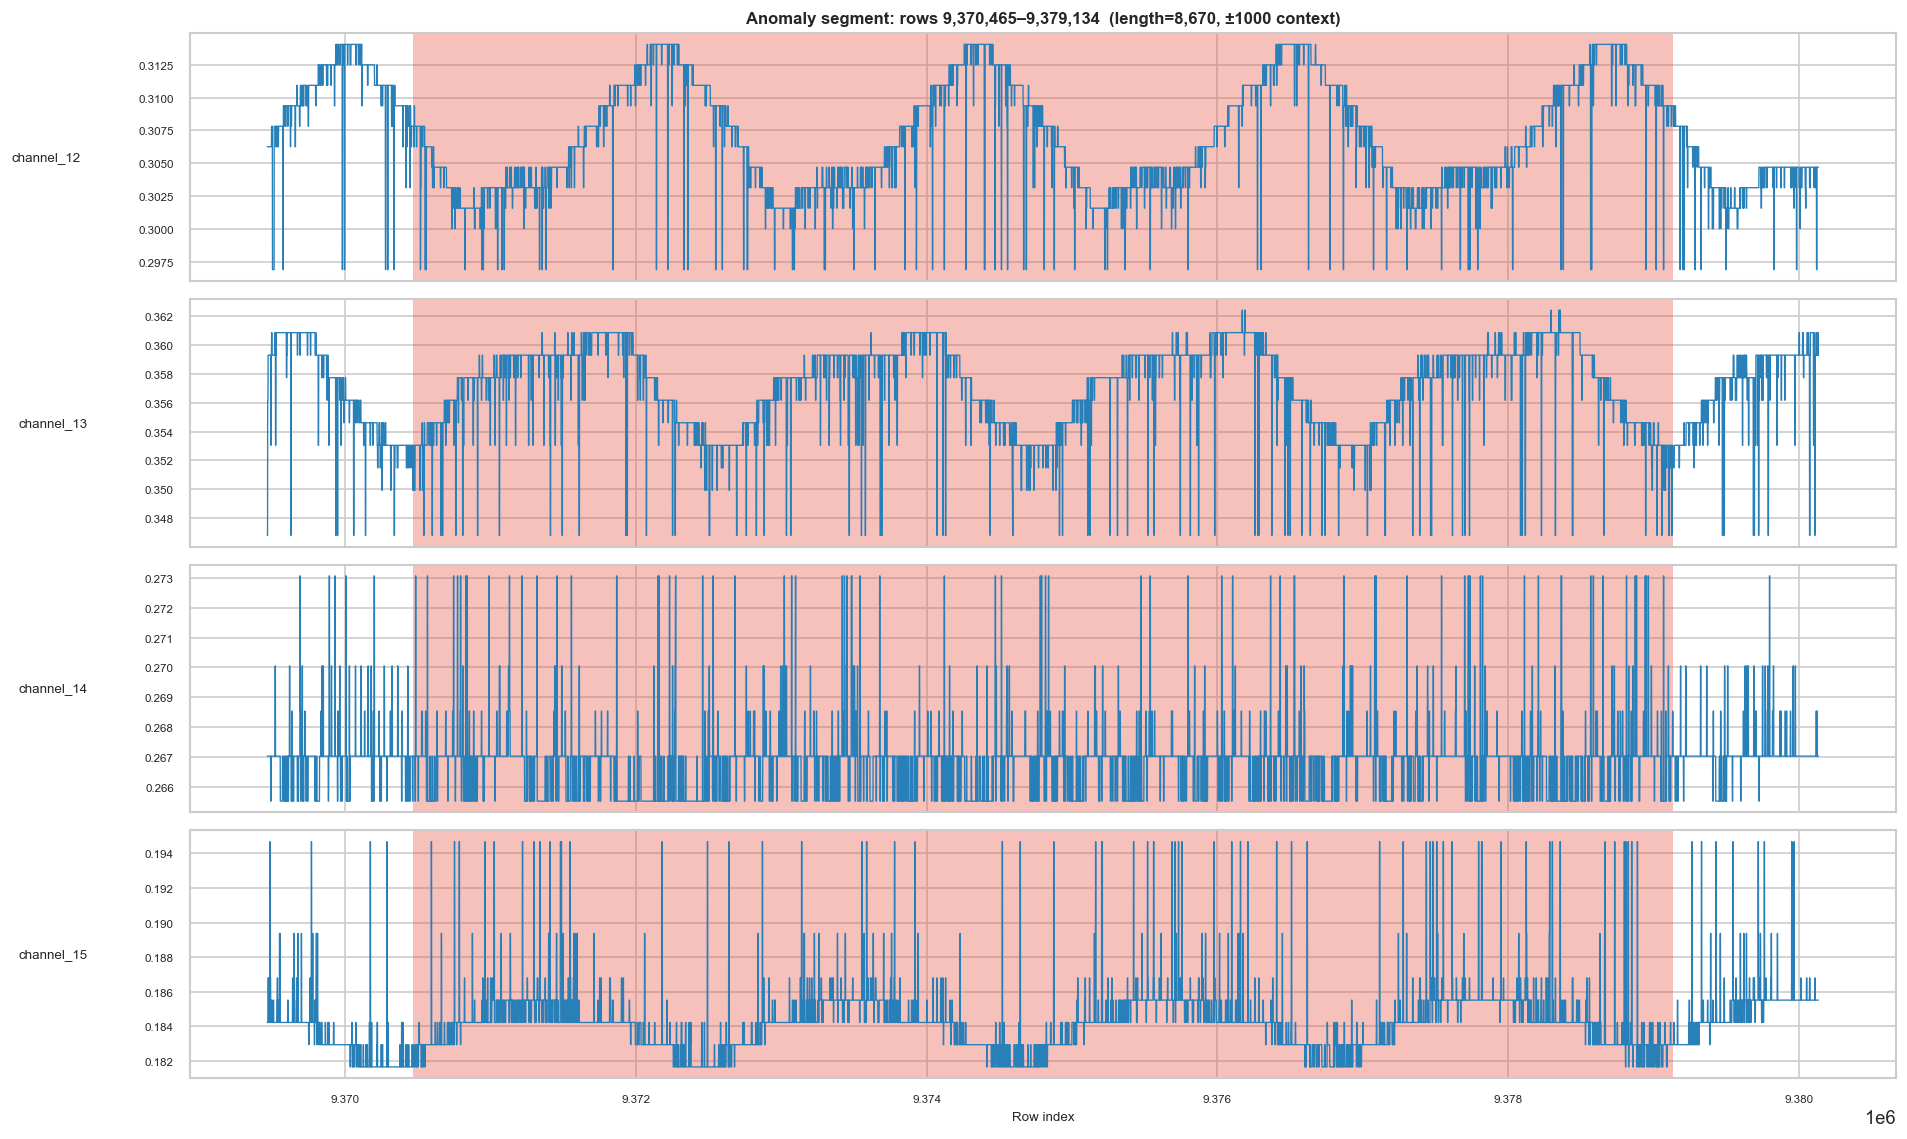

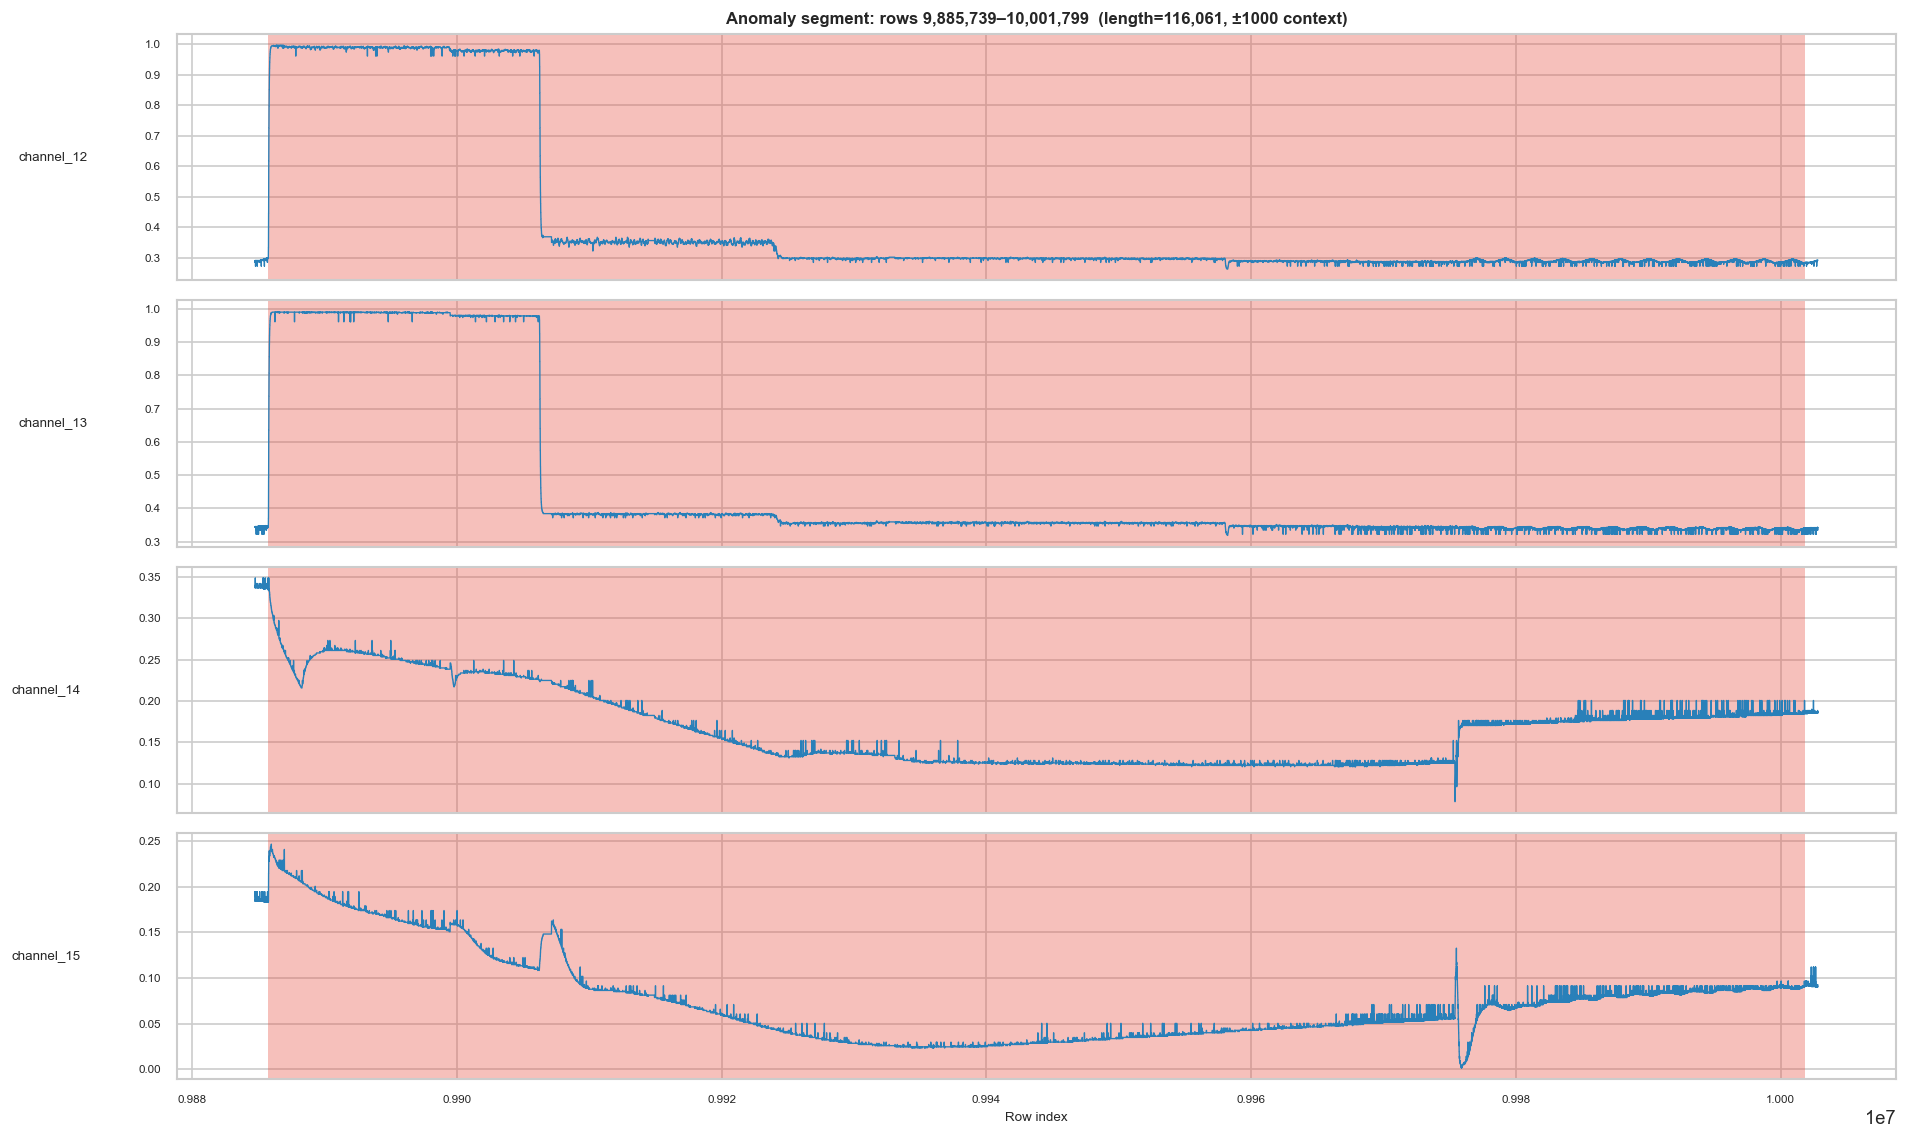

In [61]:
# Zoom into 5 specific anomaly events across different length ranges
# Pick events by length quintile
seg_df_sorted = seg_df.sort_values('length')
quintile_indices = np.linspace(0, len(seg_df)-1, 5, dtype=int)
example_segs = seg_df_sorted.iloc[quintile_indices]

ZOOM_CHANNELS = target_channels[:4]   # 4 channels in zoom plots
CONTEXT = 1000

for _, seg in example_segs.iterrows():
    lo = max(0, int(seg['start']) - CONTEXT)
    hi = min(len(train) - 1, int(seg['end']) + CONTEXT)
    sub = train.iloc[lo:hi+1]

    fig, axes = plt.subplots(len(ZOOM_CHANNELS), 1,
                              figsize=(16, 2.4 * len(ZOOM_CHANNELS)), sharex=True)
    for ax, ch in zip(axes, ZOOM_CHANNELS):
        ax.plot(sub.index, sub[ch].values, lw=0.8, color=NOMINAL_COLOR)
        # shade anomaly region
        in_anom = False; start_i = None
        for ix, v in zip(sub.index, sub['is_anomaly'].values):
            if v == 1 and not in_anom:
                start_i = ix; in_anom = True
            elif v == 0 and in_anom:
                ax.axvspan(start_i, ix, color=ANOMALY_COLOR, alpha=0.35, linewidth=0)
                in_anom = False
        if in_anom:
            ax.axvspan(start_i, sub.index[-1], color=ANOMALY_COLOR, alpha=0.35, linewidth=0)
        ax.set_ylabel(ch, fontsize=8, rotation=0, labelpad=55, va='center')
        ax.tick_params(labelsize=7)
    axes[0].set_title(
        f'Anomaly segment: rows {int(seg["start"]):,}–{int(seg["end"]):,}  '
        f'(length={int(seg["length"]):,}, ±{CONTEXT} context)',
        fontsize=10, fontweight='bold'
    )
    axes[-1].set_xlabel('Row index', fontsize=8)
    fig.tight_layout()
    plt.show()
    print()

### Channels 4–11: Pre-Differenced Counters
Channels 4–11 were originally monotonic odometer-like counters; ESA differenced them before publishing the dataset, so they hover near zero. 
The figure below confirms this - do **not** difference them again in preprocessing.

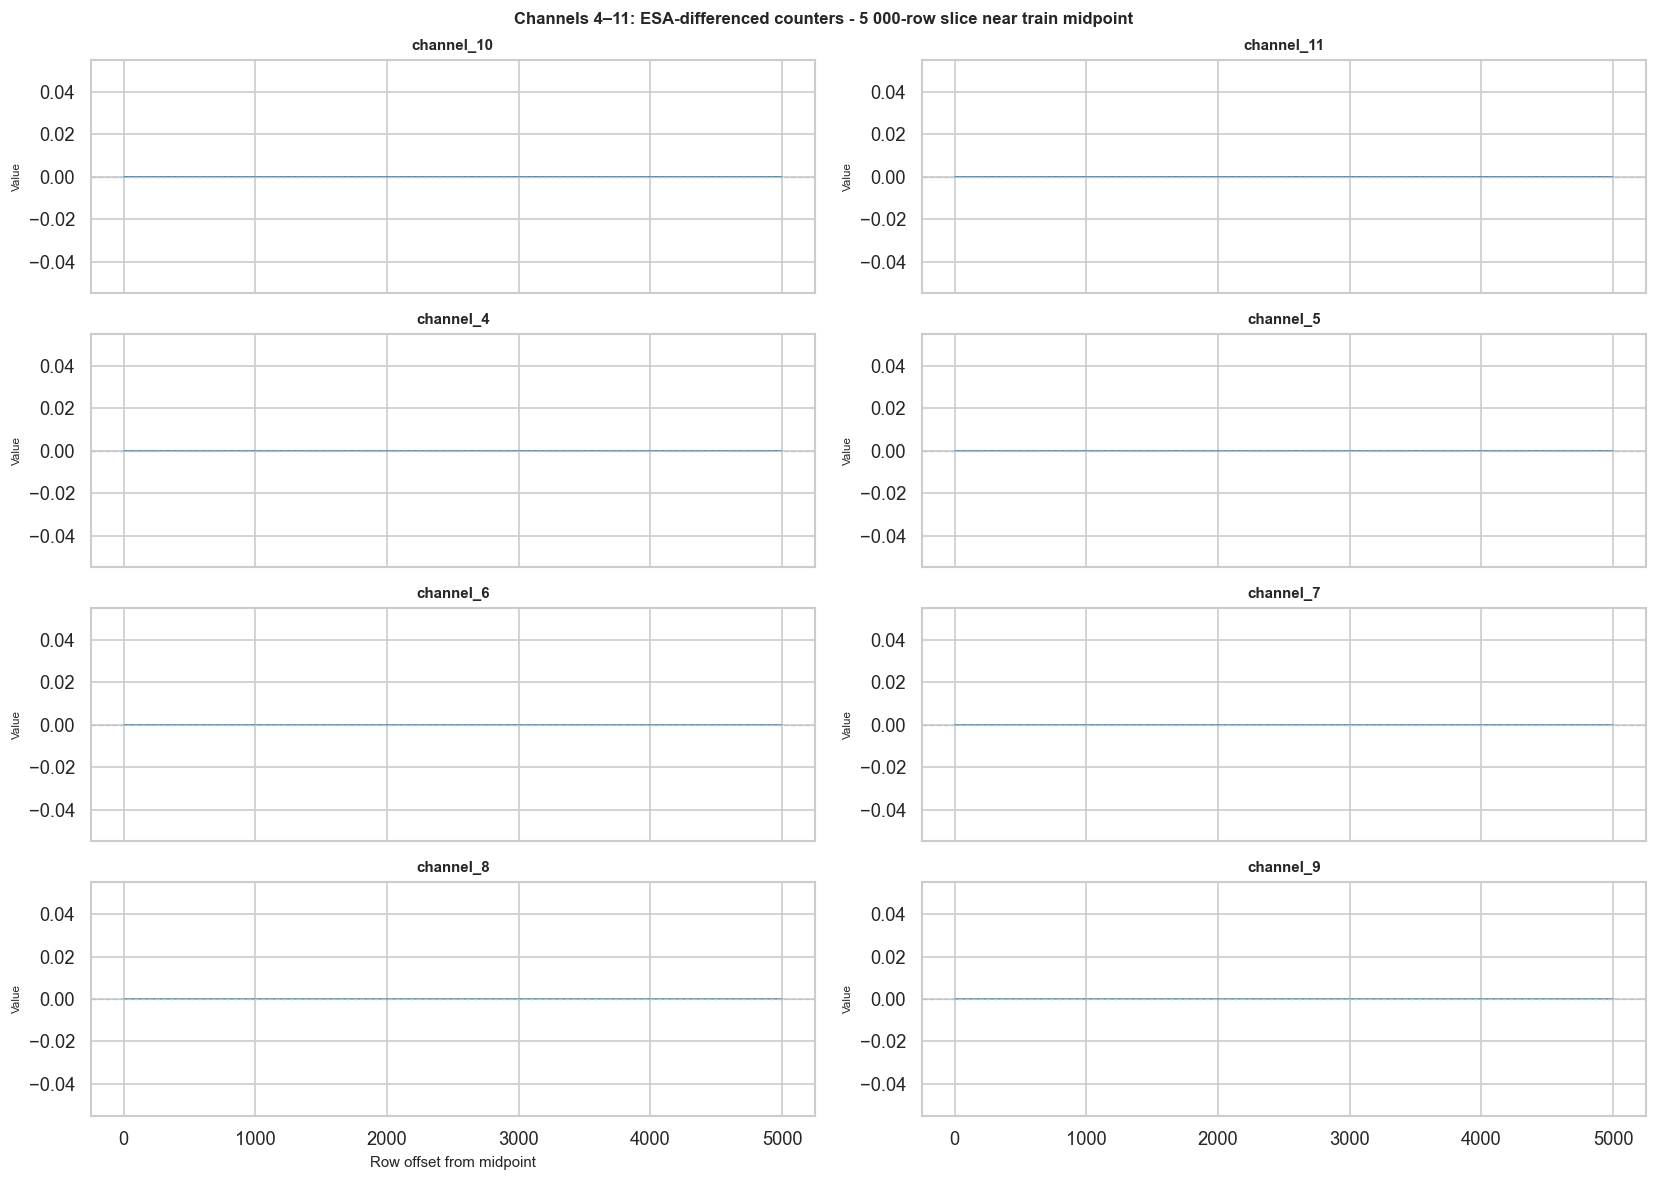

Channels 4–11 statistics (full train):
            mean       std     |max|
channel                             
channel_10   0.0  0.000001  0.000424
channel_11   0.0  0.000000  0.000422
channel_4    0.0  0.000033  0.090019
channel_5    0.0  0.000038  0.084155
channel_6    0.0  0.000042  0.113765
channel_7    0.0  0.000042  0.093788
channel_8    0.0  0.000038  0.146573
channel_9    0.0  0.000038  0.144849

Caption: these channels hover near zero and must NOT be differenced again in preprocessing.


In [62]:
# ── Channels 4–11: ESA-differenced counter waveforms ─────────────────────────
diff_channels = sorted(
    [c for c in train.columns
     if c.startswith('channel_') and c.split('_')[-1].isdigit()
     and int(c.split('_')[-1]) in range(4, 12)]
)
assert len(diff_channels) == 8, (
    f"Expected 8 diff channels, got {len(diff_channels)}: {diff_channels}"
)

# 5 000-row slice near the train midpoint
MID = len(train) // 2
slice_df = train[diff_channels].iloc[MID : MID + 5_000].reset_index(drop=True)

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()
for i, ch in enumerate(diff_channels):
    axes[i].plot(slice_df.index, slice_df[ch], lw=0.6, color=NOMINAL_COLOR)
    axes[i].set_title(ch, fontsize=9, fontweight='bold')
    axes[i].axhline(0, color='#bdc3c7', lw=0.8, ls='--')
    axes[i].set_ylabel('Value', fontsize=7)
for ax in axes[len(diff_channels):]:
    ax.set_visible(False)
axes[-2].set_xlabel('Row offset from midpoint', fontsize=9)
fig.suptitle(
    'Channels 4–11: ESA-differenced counters - 5 000-row slice near train midpoint',
    fontsize=10, fontweight='bold'
)
fig.tight_layout(); plt.show()

# Summary statistics across full train
diff_stats = pd.DataFrame([
    {'channel': ch,
     'mean':  round(float(train[ch].mean()), 6),
     'std':   round(float(train[ch].std()),  6),
     '|max|': round(float(train[ch].abs().max()), 6)}
    for ch in diff_channels
]).set_index('channel')
print('Channels 4–11 statistics (full train):')
print(diff_stats.to_string())
print('\nCaption: these channels hover near zero and must NOT be differenced again in preprocessing.')

---
## 4 - Statistical Properties

**Observations:**
- Channel distributions show varying degrees of separation between nominal and anomaly periods - some have clear bimodal splits, others overlap heavily.
- The correlation matrix reveals **block structure** - groups of channels are highly correlated, suggesting redundancy within groups.
- Rolling statistics indicate the signal is **not fully stationary**: mean and variance shift over the 14-year span, likely reflecting orbital configuration changes, seasonal effects, or mission phases.

### Channel Distributions: Nominal vs Anomaly 
Channel distributions show varying degrees of separation between nominal and anomaly periods - some have clear bimodal splits, others overlap heavily.

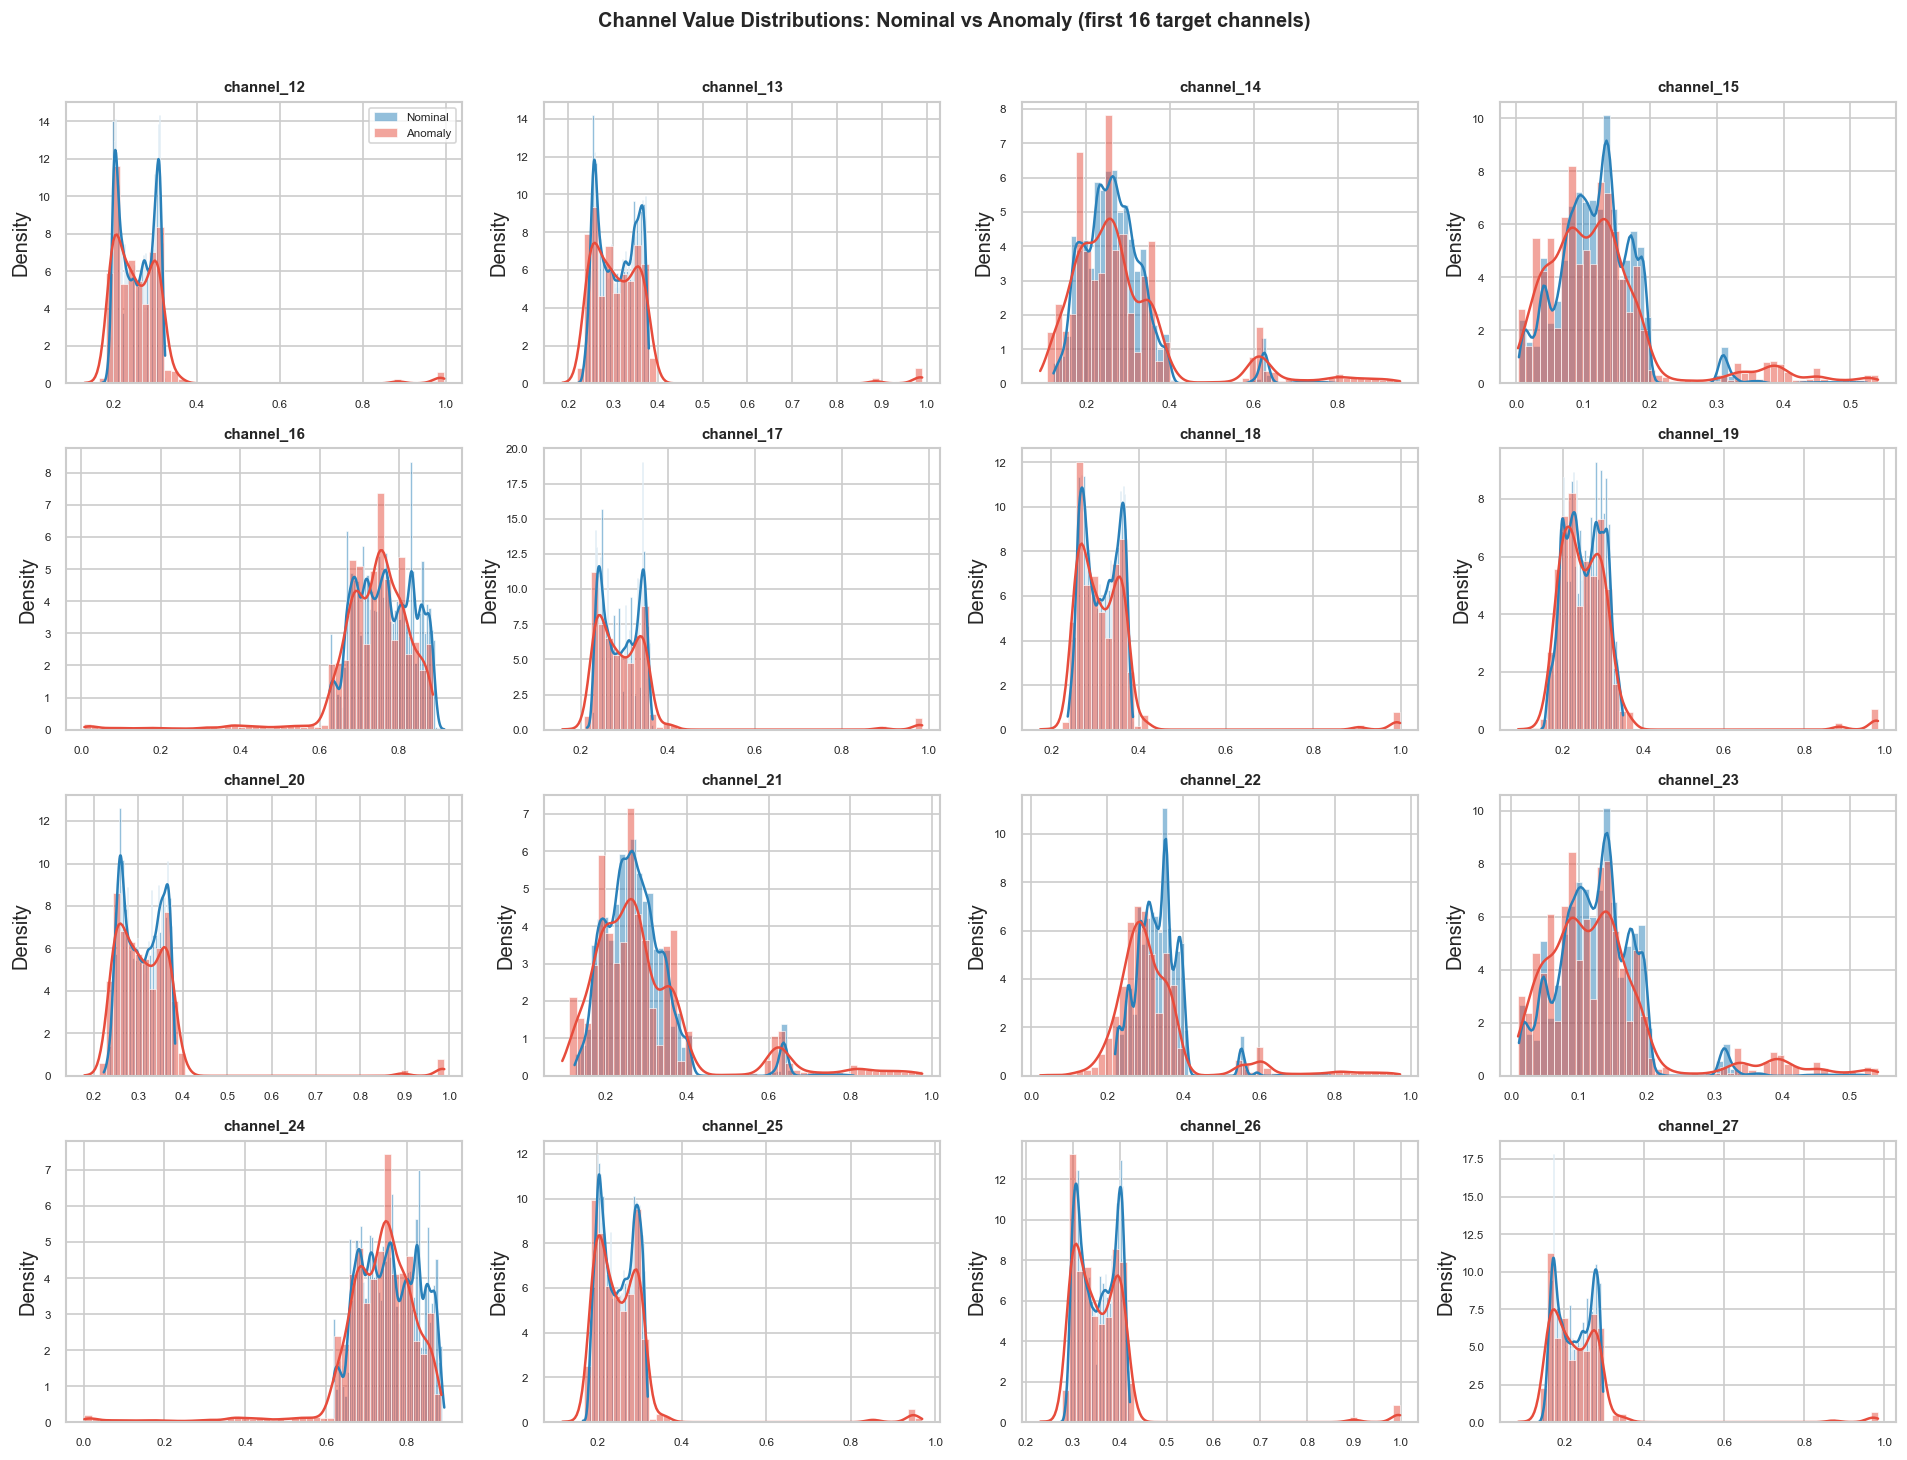

In [63]:
# Sample for distribution plots
SAMPLE_N = 100_000
train_sample = train.sample(SAMPLE_N, random_state=42)

# Histograms + KDE for first 16 target channels
DIST_CHANNELS = target_channels[:16]
ncols = 4
nrows = int(np.ceil(len(DIST_CHANNELS) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

nom_sample  = train_sample[train_sample['is_anomaly'] == 0]
anom_sample = train_sample[train_sample['is_anomaly'] == 1]

for i, ch in enumerate(DIST_CHANNELS):
    ax = axes[i]
    sns.histplot(nom_sample[ch],  ax=ax, color=NOMINAL_COLOR, alpha=0.5,
                 stat='density', bins=50, label='Nominal', kde=True)
    sns.histplot(anom_sample[ch], ax=ax, color=ANOMALY_COLOR, alpha=0.5,
                 stat='density', bins=50, label='Anomaly', kde=True)
    ax.set_title(ch, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(len(DIST_CHANNELS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Channel Value Distributions: Nominal vs Anomaly (first 16 target channels)',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### Correlation Matrix
The correlation matrix reveals **block structure** - groups of channels are highly correlated, suggesting redundancy within groups.

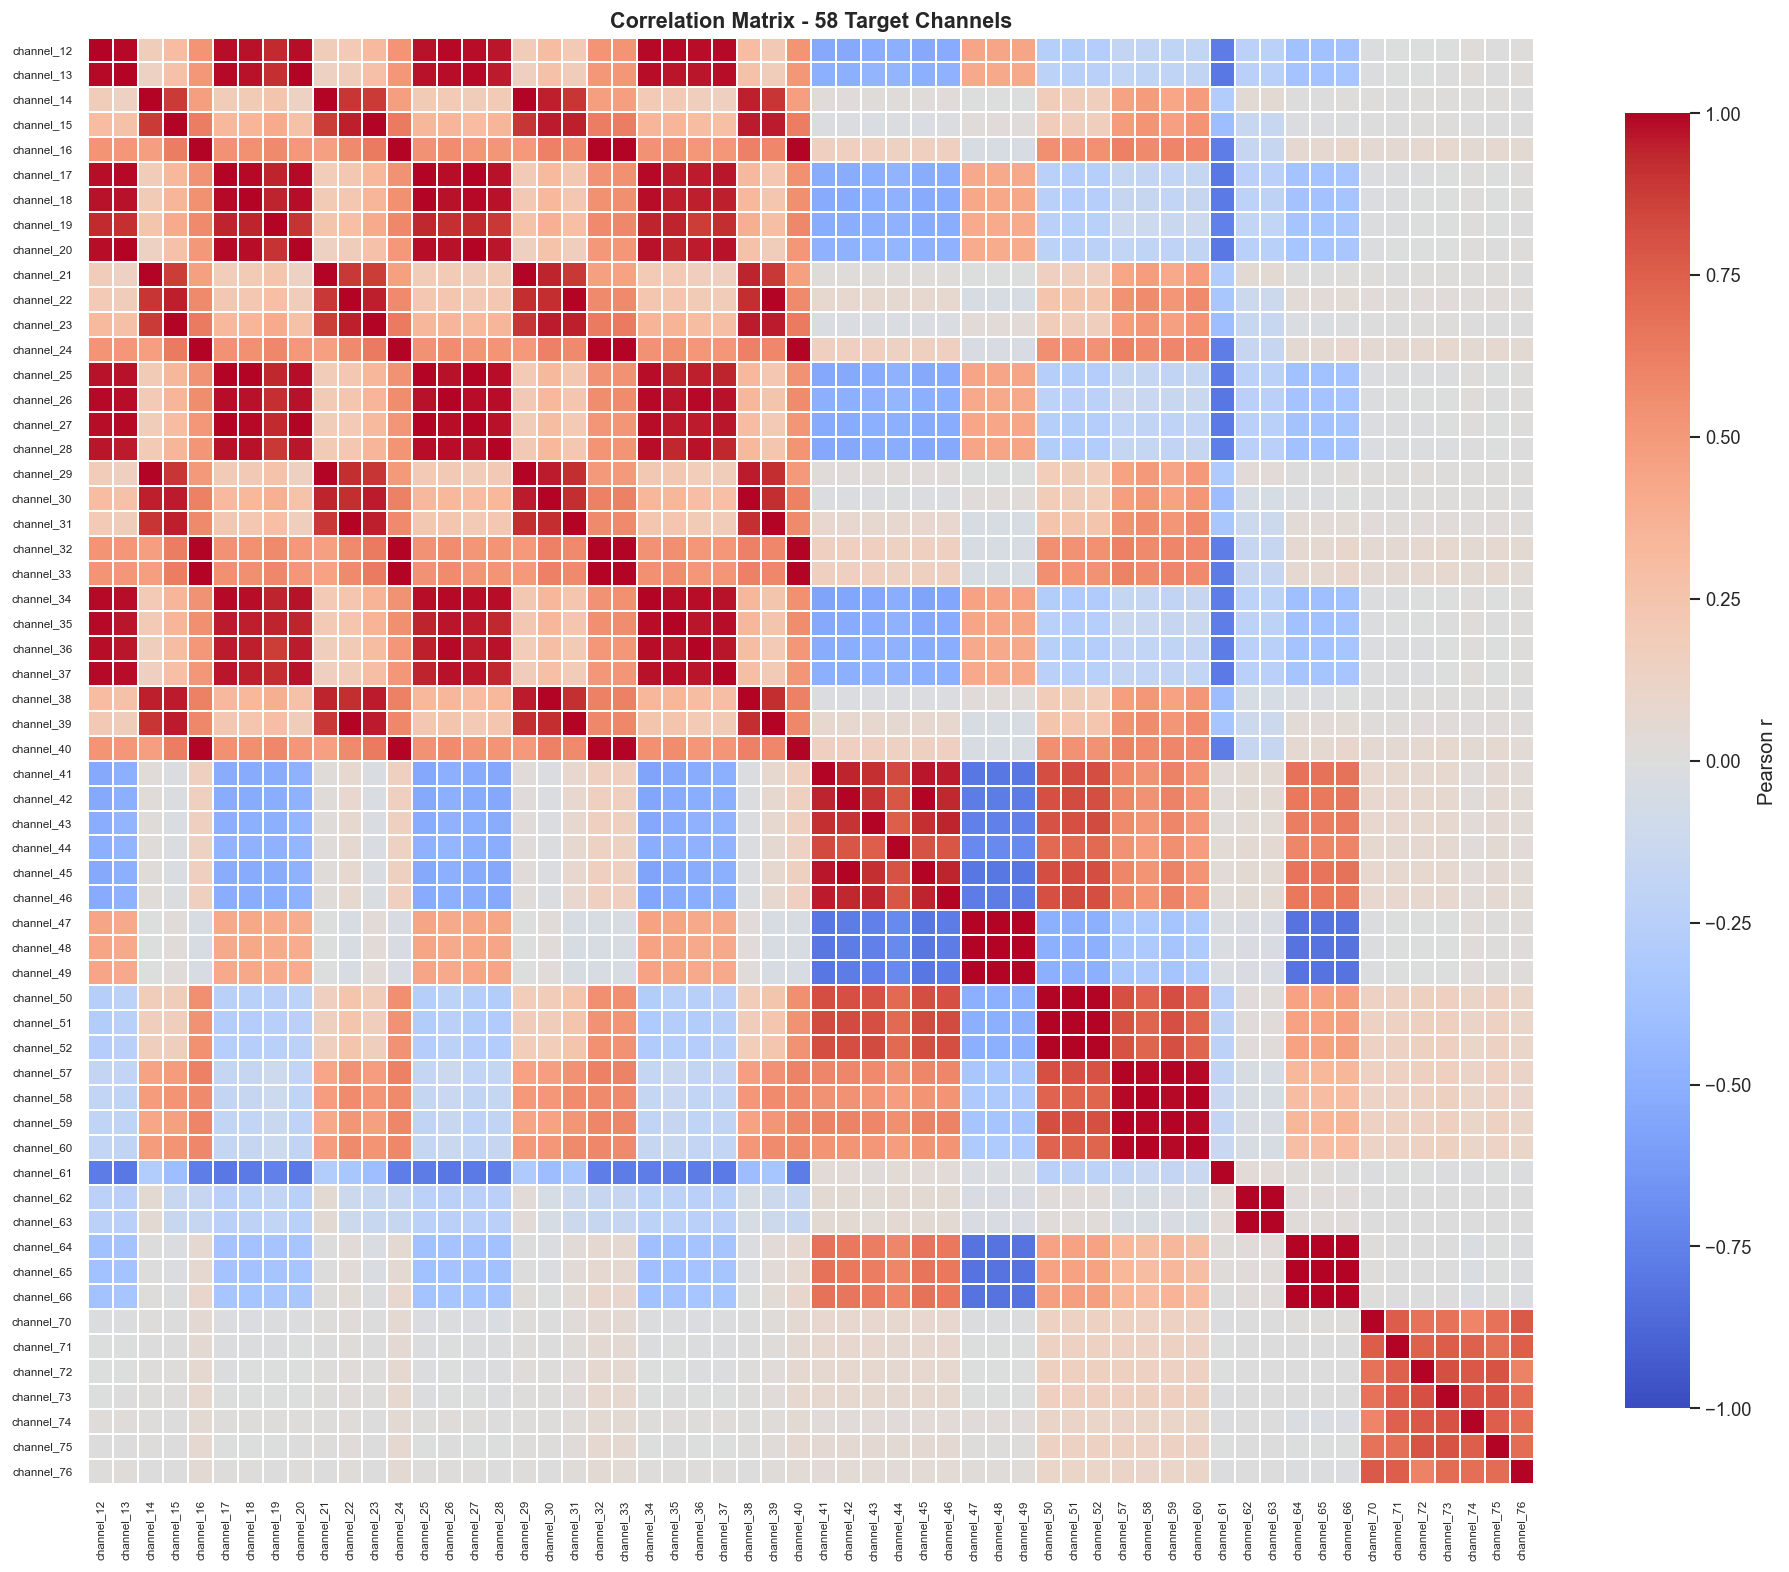

In [64]:
# Correlation matrix - target channels only
corr_sample = train[target_channels].sample(SAMPLE_N, random_state=42)
corr = corr_sample.corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr,
    ax=ax,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.2,
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
)
ax.set_title('Correlation Matrix - 58 Target Channels', fontsize=13, fontweight='bold')
ax.tick_params(labelsize=7)
fig.tight_layout()
plt.show()

### Stationarity (connected to train/test distribution shift)
- Rolling statistics indicate the signal is **not fully stationary**: mean and variance shift over the 14-year span, likely reflecting orbital configuration changes, seasonal effects, or mission phases.

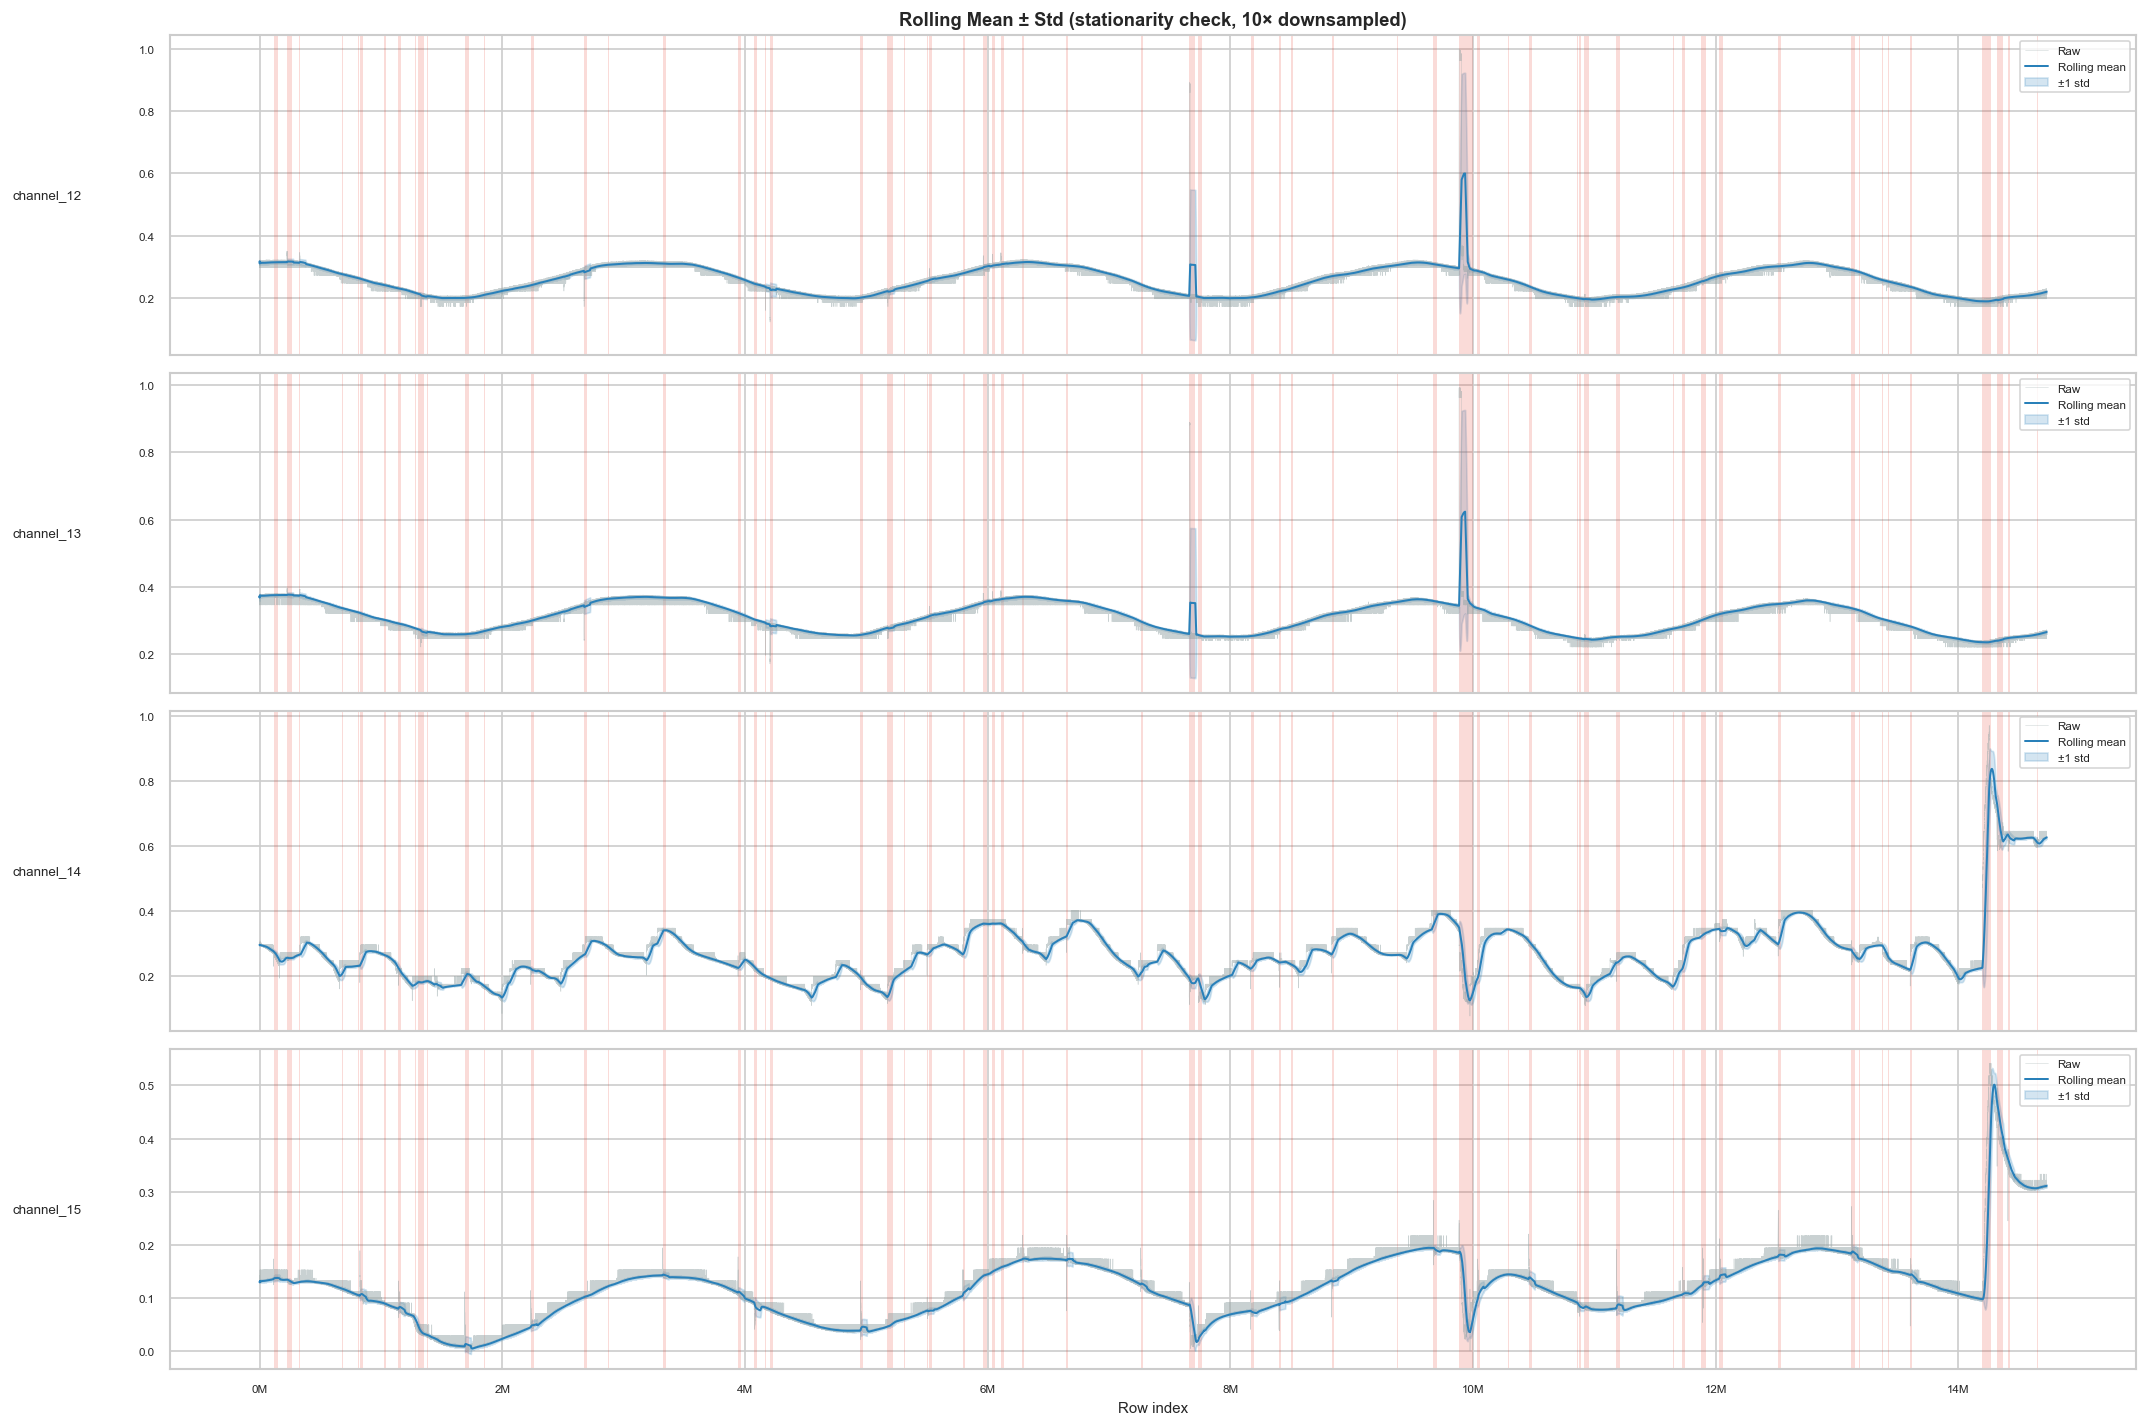

In [65]:
# Stationarity check: rolling statistics on 4 representative channels
CHECK_CHANNELS = target_channels[:4]
WINDOW = 50_000

# Use full data but downsampled for speed
train_roll = train[CHECK_CHANNELS + ['is_anomaly']].iloc[::10].copy()

fig, axes = plt.subplots(len(CHECK_CHANNELS), 1, figsize=(18, 3 * len(CHECK_CHANNELS)), sharex=True)

for ax, ch in zip(axes, CHECK_CHANNELS):
    roll_mean = train_roll[ch].rolling(WINDOW // 10, min_periods=1).mean()
    roll_std  = train_roll[ch].rolling(WINDOW // 10, min_periods=1).std()

    ax.plot(train_roll.index, train_roll[ch], lw=0.3, color='#95a5a6', alpha=0.5, label='Raw')
    ax.plot(train_roll.index, roll_mean, lw=1.2, color=NOMINAL_COLOR, label='Rolling mean')
    ax.fill_between(
        train_roll.index,
        roll_mean - roll_std,
        roll_mean + roll_std,
        alpha=0.2, color=NOMINAL_COLOR, label='±1 std'
    )
    # shade anomalies
    in_anom = False; start_i = None
    for ix, v in zip(train_roll.index, train_roll['is_anomaly'].values):
        if v == 1 and not in_anom:
            start_i = ix; in_anom = True
        elif v == 0 and in_anom:
            ax.axvspan(start_i, ix, color=ANOMALY_COLOR, alpha=0.2, linewidth=0)
            in_anom = False
    if in_anom:
        ax.axvspan(start_i, train_roll.index[-1], color=ANOMALY_COLOR, alpha=0.2, linewidth=0)

    ax.set_ylabel(ch, fontsize=8, rotation=0, labelpad=55, va='center')
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=7)

axes[0].set_title('Rolling Mean ± Std (stationarity check, 10× downsampled)',
                  fontsize=11, fontweight='bold')
axes[-1].set_xlabel('Row index', fontsize=9)
axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
fig.tight_layout()
plt.show()

---
## 5 - Channel Analysis
- A subset of target channels show **high Cohen's d** (> 0.5), meaning their means clearly separate during anomalies - these are the most useful features.
- Some channels exhibit **elevated variance** during anomalies even without a mean shift - a non-linear model that captures spread should detect these.
- Not all 58 target channels are equally informative; dimensionality reduction or feature selection may benefit modelling.

| Group | What it means for modelling |
|---|---|
| Channels 4–11 | Pre-differenced by ESA (odometer counters → hover near zero). **Do not difference again** |
| Top discriminative channels | channel_16, channel_32 show Cohen's d ≈ 0.33 - moderate mean separation between nominal and anomaly |
| High-variance channels | Some channels signal anomalies through **increased noise**, not level shifts - both patterns must be captured |
| Block correlations | Strong correlation clusters among channel groups → low-dimensional nominal manifold → PCA is a natural fit |


**Anomalies** manifest in two distinct ways: 
- **mean separation** (level shifts) -> Cohen's d 
- **variance amplification** (elevated noise without a mean shift) -> variance ratio

### Mean separation between nominal & anomaly (Cohen's d)

**Channel discriminability** means how well a single channel can tell anomalous samples apart from nominal samples, on its own.<br>
It's a per-channel diagnostic — one number per channel that answers the question "if I only had this one channel, could I distinguish anomalies from normal behaviour?"

Cohen's rough conventions:
- d ≈ 0.2 → small effect (hard to see by eye)
- d ≈ 0.5 → medium effect
- d ≈ 0.8 → large effect (clearly visible)

In [66]:
# Compute per-channel mean absolute deviation ratio: anomaly mean / nominal mean
# as a proxy for which channels "respond" most to anomalies

nom_df  = train[train['is_anomaly'] == 0]
anom_df = train[train['is_anomaly'] == 1]

# Use all target channels
ch_stats = []
for ch in target_channels:
    nom_mean  = nom_df[ch].mean()
    anom_mean = anom_df[ch].mean()
    nom_std   = nom_df[ch].std()
    anom_std  = anom_df[ch].std()
    mean_shift = abs(anom_mean - nom_mean)
    std_ratio  = anom_std / nom_std if nom_std > 0 else np.nan
    # Cohen's d
    pooled_std = np.sqrt((nom_std**2 + anom_std**2) / 2) if (nom_std + anom_std) > 0 else np.nan
    cohens_d   = mean_shift / pooled_std if pooled_std and pooled_std > 0 else np.nan

    ch_stats.append({
        'channel': ch,
        'nom_mean': nom_mean,
        'anom_mean': anom_mean,
        'mean_shift': mean_shift,
        'nom_std': nom_std,
        'anom_std': anom_std,
        'std_ratio': std_ratio,
        'cohens_d': cohens_d,
    })

ch_stats_df = pd.DataFrame(ch_stats).sort_values('cohens_d', ascending=False)
print('Top 10 channels by Cohen\'s d (mean separation between nominal & anomaly):')
ch_stats_df[['channel', 'nom_mean', 'anom_mean', 'mean_shift', 'cohens_d']].head(10)

Top 10 channels by Cohen's d (mean separation between nominal & anomaly):


,channel,nom_mean,anom_mean,mean_shift,cohens_d
4,channel_16,0.764387,0.732677,0.031710,0.334763
20,channel_32,0.772869,0.741228,0.031642,0.334090
28,channel_40,0.809992,0.778578,0.031414,0.333018
12,channel_24,0.757820,0.726294,0.031526,0.333011
21,channel_33,0.806320,0.774958,0.031362,0.332819
43,channel_59,0.890802,0.861951,0.028852,0.317654
41,channel_57,0.788898,0.762071,0.026827,0.314739
40,channel_52,0.758240,0.732134,0.026106,0.308537
38,channel_50,0.753768,0.728412,0.025356,0.306718
39,channel_51,0.777696,0.751810,0.025886,0.302695


### Visualizations most discriminative channels by mean separation

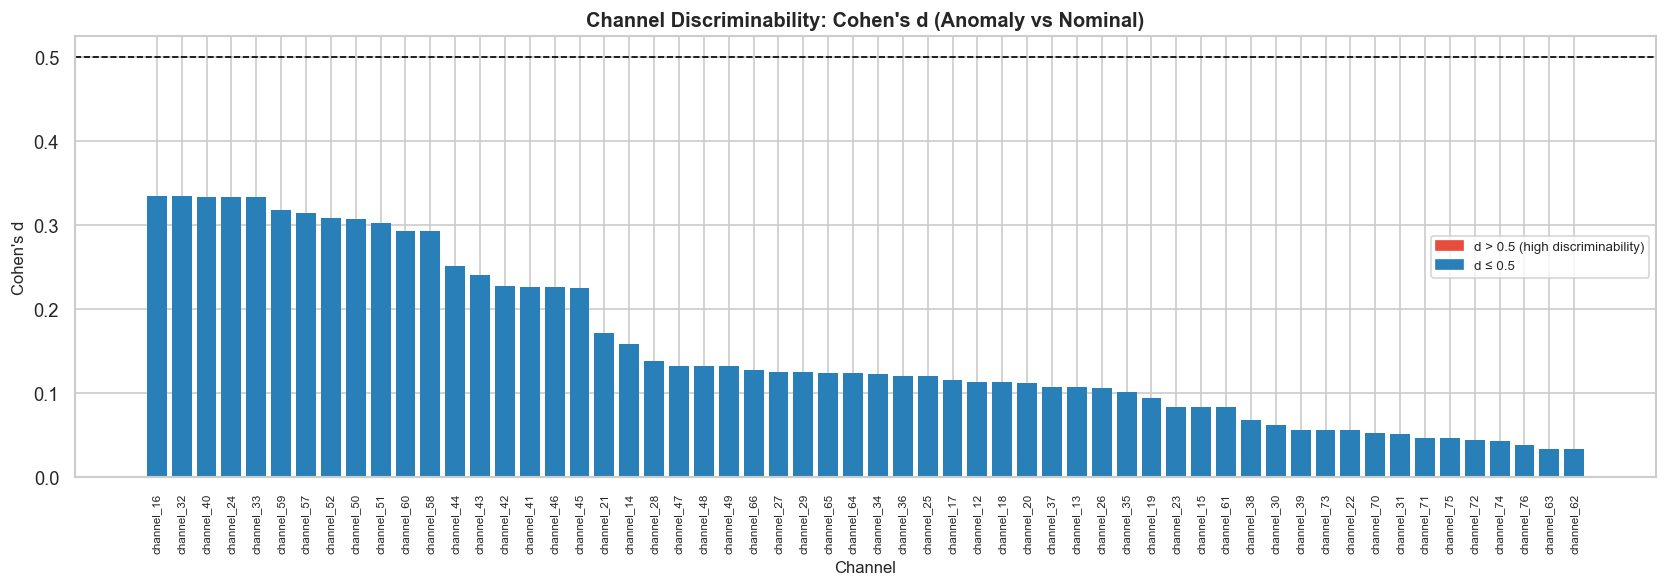

In [67]:
# Bar chart: Cohen's d per channel
fig, ax = plt.subplots(figsize=(14, 5))

palette = [ANOMALY_COLOR if d > 0.5 else NOMINAL_COLOR for d in ch_stats_df['cohens_d']]
ax.bar(ch_stats_df['channel'], ch_stats_df['cohens_d'], color=palette, edgecolor='none')
ax.axhline(0.5, color='black', ls='--', lw=1, label="Cohen's d = 0.5 (medium effect)")
ax.set_xlabel('Channel', fontsize=10)
ax.set_ylabel("Cohen's d", fontsize=10)
ax.set_title("Channel Discriminability: Cohen's d (Anomaly vs Nominal)",
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend(fontsize=9)

highlight = mpatches.Patch(color=ANOMALY_COLOR, label="d > 0.5 (high discriminability)")
low       = mpatches.Patch(color=NOMINAL_COLOR, label="d ≤ 0.5")
ax.legend(handles=[highlight, low], fontsize=8)

fig.tight_layout()
plt.show()

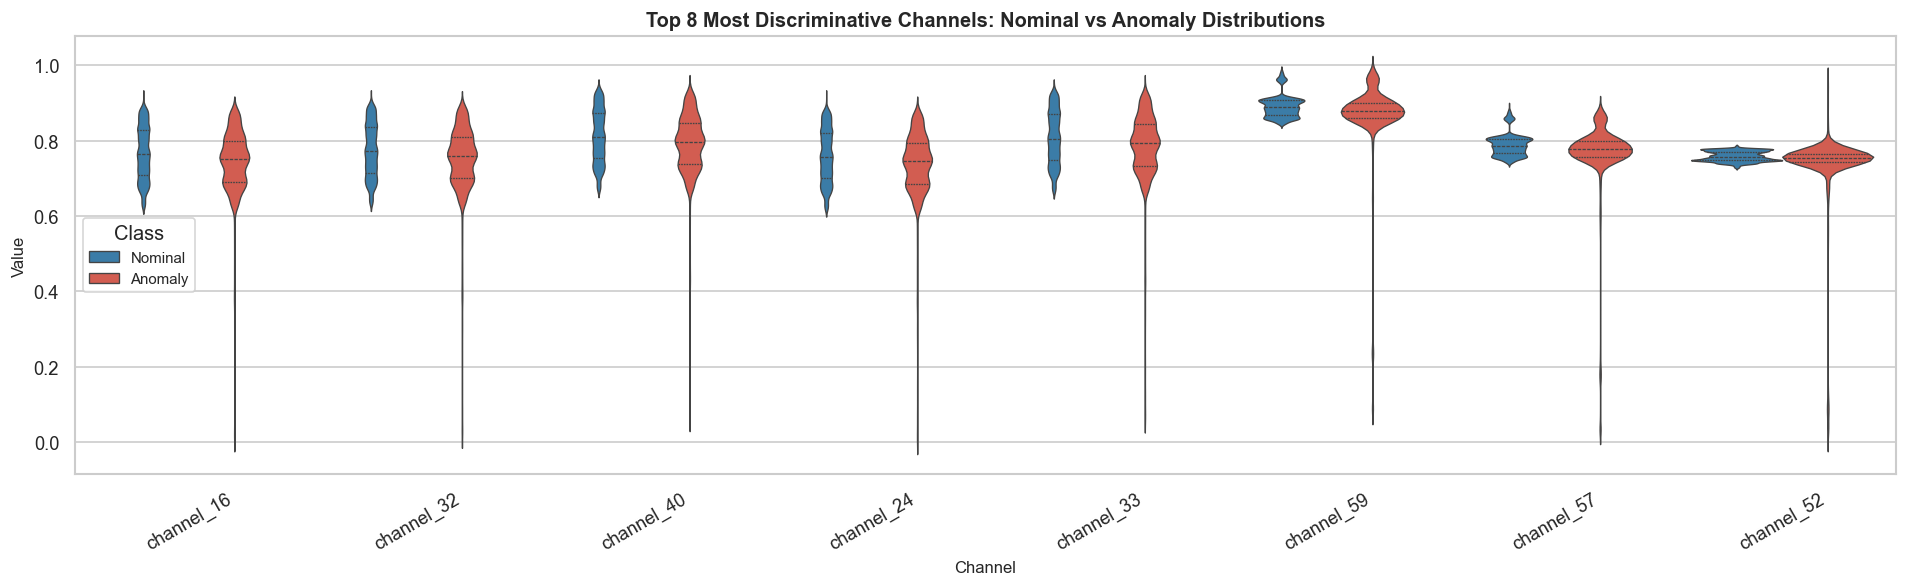

In [68]:
# Violin plots: top 8 most discriminative channels
top_channels = ch_stats_df['channel'].head(8).tolist()

# Sample for speed
VIOLIN_N = 20_000
nom_v  = nom_df[top_channels].sample(min(VIOLIN_N, len(nom_df)),  random_state=42).copy()
anom_v = anom_df[top_channels].sample(min(VIOLIN_N, len(anom_df)), random_state=42).copy()

nom_v['_label']  = 'Nominal'
anom_v['_label'] = 'Anomaly'
combined = pd.concat([nom_v, anom_v])

melted = combined.melt(id_vars='_label', value_vars=top_channels,
                        var_name='channel', value_name='value')

fig, ax = plt.subplots(figsize=(16, 5))
sns.violinplot(
    data=melted, x='channel', y='value', hue='_label',
    inner='quartile',
    palette={'Nominal': NOMINAL_COLOR, 'Anomaly': ANOMALY_COLOR},
    ax=ax, linewidth=0.8,
)
ax.set_title('Top 8 Most Discriminative Channels: Nominal vs Anomaly Distributions',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Channel', fontsize=10)
ax.set_ylabel('Value', fontsize=10)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Class', fontsize=9)
fig.tight_layout()
plt.show()

### Varinace 

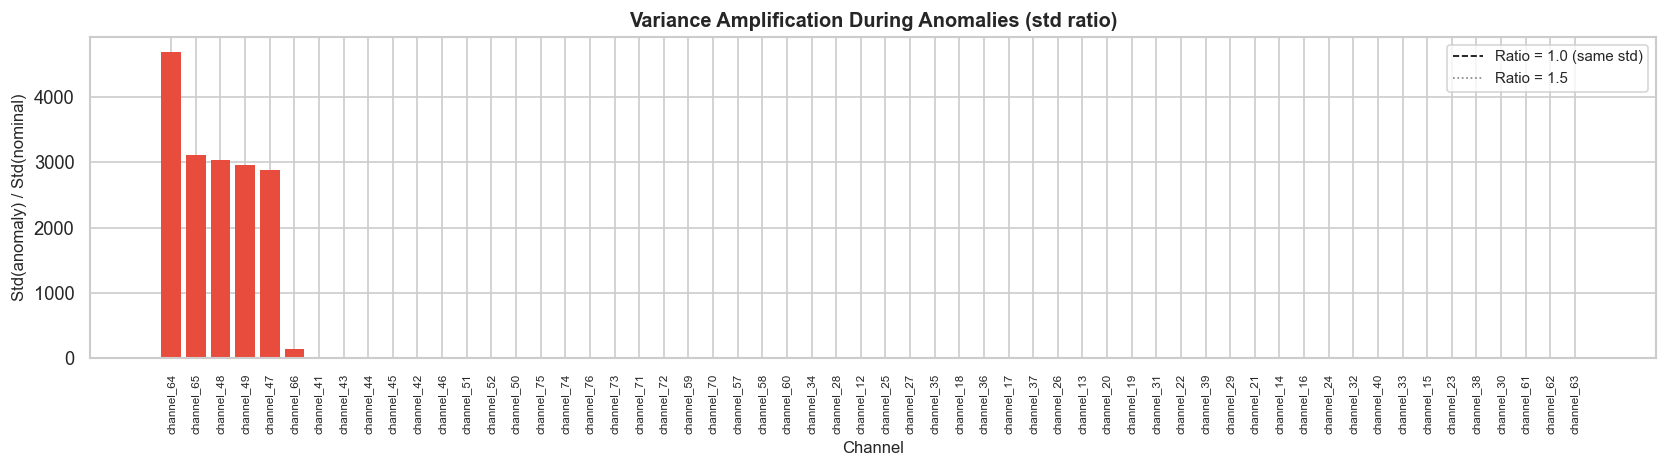

In [69]:
# STD ratio chart: which channels have higher variance during anomalies?
std_df = ch_stats_df.sort_values('std_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
colors = [ANOMALY_COLOR if r > 1.5 else NOMINAL_COLOR for r in std_df['std_ratio']]
ax.bar(std_df['channel'], std_df['std_ratio'], color=colors, edgecolor='none')
ax.axhline(1.0, color='black', ls='--', lw=1, label='Ratio = 1.0 (same std)')
ax.axhline(1.5, color='gray', ls=':', lw=1, label='Ratio = 1.5')
ax.set_xlabel('Channel', fontsize=10)
ax.set_ylabel('Std(anomaly) / Std(nominal)', fontsize=10)
ax.set_title('Variance Amplification During Anomalies (std ratio)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

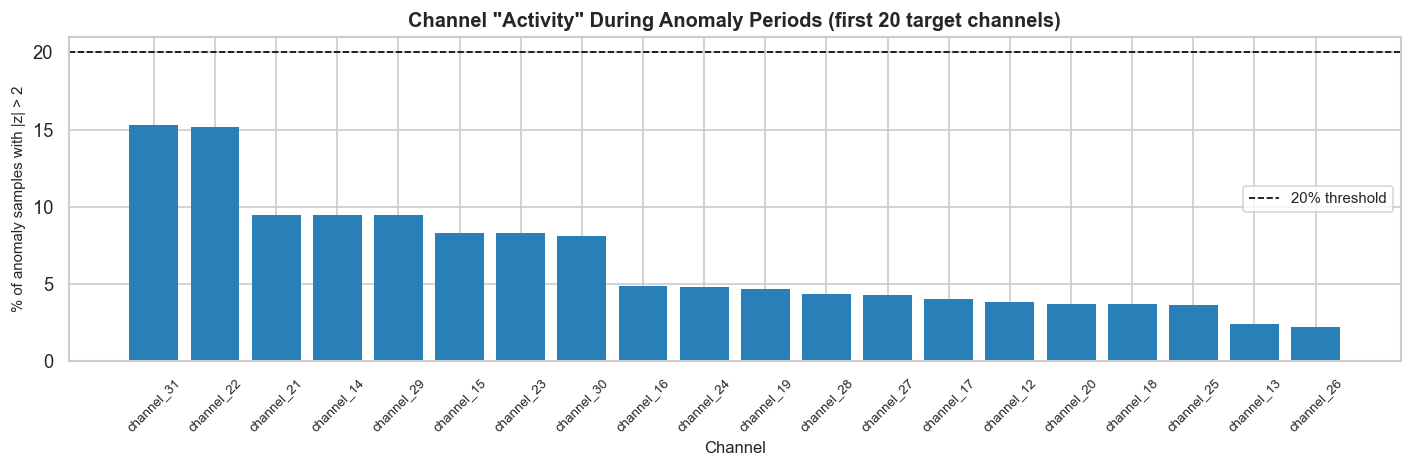

In [70]:
# Fraction of anomaly time each channel is "active" (significantly deviated)
# Simple proxy: |z-score| > 2 during anomaly windows
from scipy.stats import zscore

ZSCORE_CHANNELS = target_channels[:20]
anom_activity = {}

# Compute z-score thresholds from nominal data
nom_means = nom_df[ZSCORE_CHANNELS].mean()
nom_stds  = nom_df[ZSCORE_CHANNELS].std().replace(0, 1e-9)

anom_z = ((anom_df[ZSCORE_CHANNELS] - nom_means) / nom_stds).abs()
frac_deviated = (anom_z > 2).mean()

fig, ax = plt.subplots(figsize=(12, 4))
frac_deviated_sorted = frac_deviated.sort_values(ascending=False)
colors = [ANOMALY_COLOR if f > 0.2 else NOMINAL_COLOR for f in frac_deviated_sorted]
ax.bar(frac_deviated_sorted.index, frac_deviated_sorted.values * 100,
       color=colors, edgecolor='none')
ax.axhline(20, color='black', ls='--', lw=1, label='20% threshold')
ax.set_xlabel('Channel', fontsize=10)
ax.set_ylabel('% of anomaly samples with |z| > 2', fontsize=9)
ax.set_title('Channel "Activity" During Anomaly Periods (first 20 target channels)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 6 - Train vs Test Distribution
- **Mean KS distance across 58 channels = 0.43** - distributions are substantially different between train and test
- **Top shifted channels**: channel_15 (KS = 0.97), channel_23 (0.97), channel_38 (0.97) - nearly completely separated
- These channels have much higher means in test than in train (e.g. channel_14: train mean 0.27 → test mean 0.64)

Train covers ~14 years of continuous telemetry; test covers the next ~6 months. Mission phases, orbital configurations, and operating modes may differ between the two periods, causing **distribution shift** in individual sensor channels. 

We quantify this per-channel using:
- **|Δmean|** - absolute difference in per-channel mean
- **Std ratio** - test std / train std (values far from 1.0 indicate variance change)
- **KS distance** - Kolmogorov–Smirnov statistic (0 = identical, 1 = fully separated)

High KS distance signals that a threshold optimised on validation data may not transfer reliably to test - the root cause of the `per_row/max` scoring failure documented in PC Baseline. 

**Why Distribution Shift Matters for This Metric**
The ESA-ADB score threshold is tuned on validation data, then applied to test. For the threshold to transfer cleanly, score distributions must be in the same dynamic range:
- `window_mean` MSE: val max ≈ 1,178 - test max ≈ 1.31 - **same order of magnitude** → threshold transfers.
- `per_row/max` MSE: val max ≈ 19,528 - test max ≈ 124.7 - **157× gap** → optimal val threshold sits above 99.99% of test scores → only 4 test rows flagged → Kaggle 0.277.

Channels with high KS distance (largest train/test distribution shift) are the likely source of score variance inflation in val relative to test. They are candidates for closer inspection in future models.

In [71]:
# ── Train vs Test Distribution - per-channel KS analysis ────────────────
# Load test, align to 58 scored target channels, compute per-channel stats
# and KS distance to quantify distribution shift.

test_target = test[target_channels]

train_stats_27 = pd.DataFrame({
    'channel':    target_channels,
    'train_mean': [float(train[c].mean()) for c in target_channels],
    'train_std':  [float(train[c].std())  for c in target_channels],
})
test_stats_27 = pd.DataFrame({
    'channel':   target_channels,
    'test_mean': [float(test_target[c].mean()) for c in target_channels],
    'test_std':  [float(test_target[c].std())  for c in target_channels],
})

SAMPLE_KS = 50_000  # cap for speed on 14.7 M train rows
_rng_ks   = 42

ks_rows = []
for ch in target_channels:
    tr_samp = train[ch].sample(min(SAMPLE_KS, len(train)),
                               random_state=_rng_ks).values
    te_samp = test_target[ch].sample(min(SAMPLE_KS, len(test_target)),
                                     random_state=_rng_ks).values
    ks_stat, _ = stats.ks_2samp(tr_samp, te_samp)
    ks_rows.append({'channel': ch, 'ks_stat': float(ks_stat)})

ks_df = (train_stats_27
         .merge(test_stats_27, on='channel')
         .merge(pd.DataFrame(ks_rows), on='channel'))

ks_df['mean_diff'] = (ks_df['train_mean'] - ks_df['test_mean']).abs()
ks_df['std_ratio'] = (ks_df['test_std']
                      / ks_df['train_std'].replace(0, float('nan')))

print(f'Channels analysed : {len(ks_df)}')
print(f'Mean KS distance  : {ks_df["ks_stat"].mean():.4f}')
_max_ch = ks_df.loc[ks_df["ks_stat"].idxmax(), "channel"]
_min_ch = ks_df.loc[ks_df["ks_stat"].idxmin(), "channel"]
print(f'Max KS distance   : {ks_df["ks_stat"].max():.4f}  ({_max_ch})')
print(f'Min KS distance   : {ks_df["ks_stat"].min():.4f}  ({_min_ch})')
print()
print('Top 10 channels by KS distance:')
cols_show = ['channel', 'train_mean', 'test_mean', 'mean_diff',
             'train_std', 'test_std', 'std_ratio', 'ks_stat']
print(ks_df.nlargest(10, 'ks_stat')[cols_show].round(4).to_string(index=False))

Channels analysed : 58
Mean KS distance  : 0.4311
Max KS distance   : 0.9728  (channel_15)
Min KS distance   : 0.0008  (channel_64)

Top 10 channels by KS distance:
   channel  train_mean  test_mean  mean_diff  train_std  test_std  std_ratio  ks_stat
channel_15      0.1210     0.3289     0.2079     0.0653    0.0142     0.2172   0.9728
channel_23      0.1269     0.3337     0.2069     0.0650    0.0141     0.2163   0.9707
channel_38      0.1505     0.4211     0.2706     0.0767    0.0140     0.1824   0.9656
channel_30      0.1509     0.4253     0.2744     0.0770    0.0141     0.1830   0.9656
channel_14      0.2720     0.6401     0.3681     0.0958    0.0162     0.1692   0.9635
channel_29      0.2911     0.6431     0.3519     0.0912    0.0161     0.1767   0.9635
channel_21      0.2784     0.6519     0.3734     0.0976    0.0163     0.1673   0.9634
channel_22      0.3335     0.5698     0.2363     0.0728    0.0147     0.2014   0.9632
channel_39      0.3362     0.5722     0.2360     0.0735    0.

### Distribution shift visualisation 

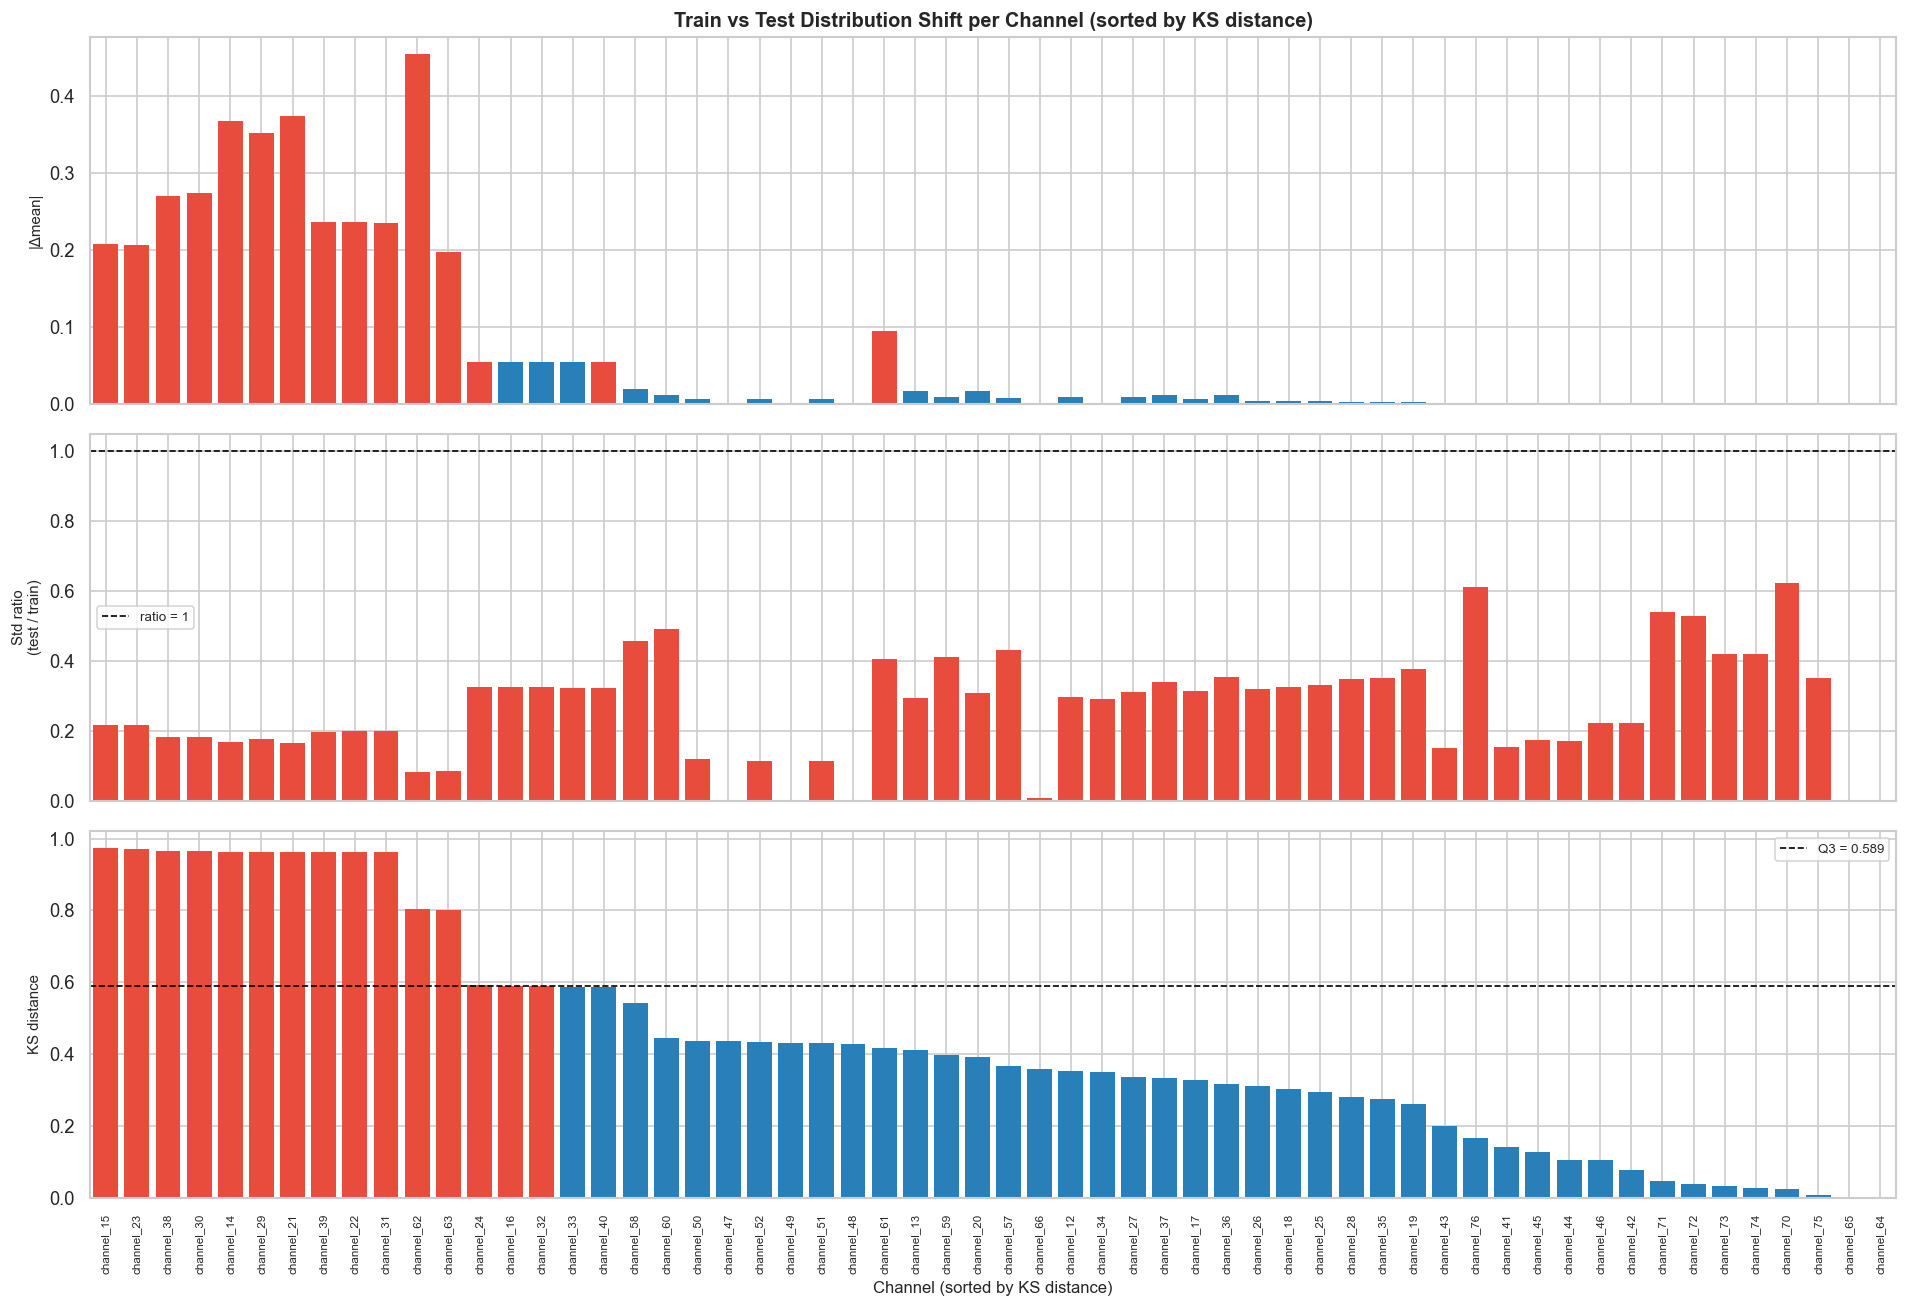

Top 5 channels by KS distance (highest distribution shift):
   channel  mean_diff  std_ratio  ks_stat
channel_15   0.207888   0.217152  0.97278
channel_23   0.206865   0.216314  0.97072
channel_38   0.270609   0.182424  0.96564
channel_30   0.274425   0.182965  0.96556
channel_14   0.368103   0.169220  0.96352


In [72]:
# Three panels (all sorted by KS distance):
#   1. |Δmean|  (absolute mean difference)
#   2. Std ratio (test_std / train_std)
#   3. KS distance

ks_sorted = ks_df.sort_values('ks_stat', ascending=False)
q75_mean = ks_sorted['mean_diff'].quantile(0.75)
q75_ks   = ks_sorted['ks_stat'].quantile(0.75)

fig, axes = plt.subplots(3, 1, figsize=(16, 11))

# Panel 1: absolute mean difference
ax = axes[0]
c1 = [ANOMALY_COLOR if v > q75_mean else NOMINAL_COLOR for v in ks_sorted['mean_diff']]
ax.bar(ks_sorted['channel'], ks_sorted['mean_diff'], color=c1, edgecolor='none')
ax.set_ylabel('|Δmean|', fontsize=9)
ax.set_title('Train vs Test Distribution Shift per Channel (sorted by KS distance)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelbottom=False)
ax.set_xlim(-0.5, len(ks_sorted) - 0.5)

# Panel 2: std ratio
ax2 = axes[1]
c2 = [ANOMALY_COLOR if (v > 1.5 or v < 0.67) else NOMINAL_COLOR
      for v in ks_sorted['std_ratio']]
ax2.bar(ks_sorted['channel'], ks_sorted['std_ratio'], color=c2, edgecolor='none')
ax2.axhline(1.0, color='black', ls='--', lw=1, label='ratio = 1')
ax2.set_ylabel('Std ratio\n(test / train)', fontsize=9)
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', labelbottom=False)
ax2.set_xlim(-0.5, len(ks_sorted) - 0.5)

# Panel 3: KS distance
ax3 = axes[2]
c3 = [ANOMALY_COLOR if v > q75_ks else NOMINAL_COLOR for v in ks_sorted['ks_stat']]
ax3.bar(ks_sorted['channel'], ks_sorted['ks_stat'], color=c3, edgecolor='none')
ax3.axhline(q75_ks, color='black', ls='--', lw=1, label=f'Q3 = {q75_ks:.3f}')
ax3.set_ylabel('KS distance', fontsize=9)
ax3.set_xlabel('Channel (sorted by KS distance)', fontsize=10)
ax3.legend(fontsize=8)
ax3.tick_params(axis='x', rotation=90, labelsize=7)
ax3.set_xlim(-0.5, len(ks_sorted) - 0.5)

fig.tight_layout()
plt.show()

print('Top 5 channels by KS distance (highest distribution shift):')
print(ks_df.nlargest(5, 'ks_stat')[
    ['channel', 'mean_diff', 'std_ratio', 'ks_stat']
].to_string(index=False))

---
## 8 - Telecommand Co-occurrence
- All 11 telecommands fire with **lift > 6× inside anomaly windows** (most ≈ 9.5×)
- Absolute firing counts are tiny (≤ 56 total across 14.7M rows)
- **Interpretation:** operators respond to faults by sending commands - telecommands are a *consequence* of anomalies, not a causal predictor

Telecommand columns record when ground operators sent commands to the spacecraft. We measure **lift** = (fraction of anomaly rows with a firing) / (baseline firing rate) to check whether any telecommand is systematically associated with anomaly windows - a high lift would suggest operators responded to faults, or that commands may have triggered them. Given the extremely low overall activation rate (< 0.0005%), even a single co-firing with a large anomaly event can inflate lift significantly.

Telecommand co-occurrence with anomaly windows (sorted by lift):
    telecommand  fires_all  fires_anom    base_rate  anom_rate     lift
telecommand_352         26          26 1.765306e-06   0.000017 9.538426
telecommand_353         28          28 1.901099e-06   0.000018 9.538426
telecommand_354         28          28 1.901099e-06   0.000018 9.538426
telecommand_350         56          55 3.802198e-06   0.000036 9.368096
telecommand_376         46          45 3.123234e-06   0.000029 9.331068
 telecommand_39         38          37 2.580063e-06   0.000024 9.287414
 telecommand_40         38          37 2.580063e-06   0.000024 9.287414
telecommand_244         13          12 8.826532e-07   0.000008 8.804700
telecommand_351         24          22 1.629514e-06   0.000014 8.743557
 telecommand_36         66          45 4.481163e-06   0.000029 6.503472
 telecommand_38         35          14 2.376374e-06   0.000009 3.815370


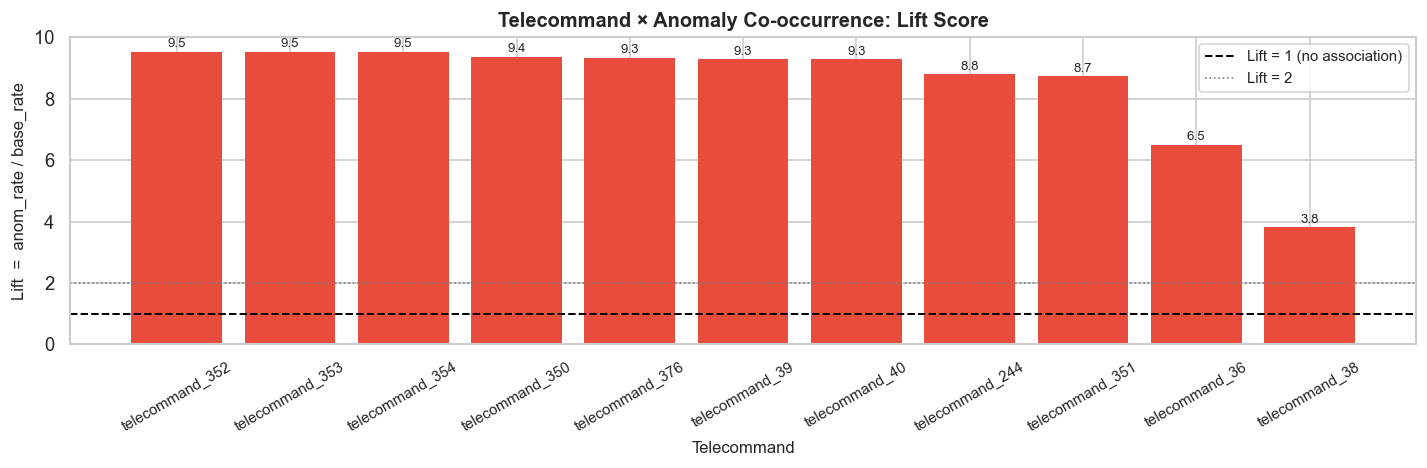

In [73]:
# ── 2.9  Telecommand × Anomaly Co-occurrence ─────────────────────────────────
# For each telecommand compute:
#   base_rate  = fraction of ALL rows where it fires
#   anom_rate  = fraction of ANOMALY rows where it fires
#   lift       = anom_rate / base_rate  (> 1 means co-occurs with anomalies)

tc_cooc = []
N_all_tc  = len(train)
N_anom_tc = int(train['is_anomaly'].sum())
N_nom_tc  = N_all_tc - N_anom_tc

for tc in telecommand_cols:
    fires_all  = int(train[tc].sum())
    fires_anom = int(train.loc[train['is_anomaly'] == 1, tc].sum())
    fires_nom  = fires_all - fires_anom

    base_rate = fires_all  / N_all_tc  if N_all_tc  > 0 else 0.0
    anom_rate = fires_anom / N_anom_tc if N_anom_tc > 0 else 0.0
    nom_rate  = fires_nom  / N_nom_tc  if N_nom_tc  > 0 else 0.0
    lift      = anom_rate  / base_rate if base_rate > 0 else float('nan')

    tc_cooc.append({
        'telecommand': tc,
        'fires_all': fires_all,
        'fires_anom': fires_anom,
        'fires_nom': fires_nom,
        'base_rate': base_rate,
        'anom_rate': anom_rate,
        'nom_rate': nom_rate,
        'lift': lift,
    })

cooc_df = pd.DataFrame(tc_cooc).sort_values('lift', ascending=False)
print('Telecommand co-occurrence with anomaly windows (sorted by lift):')
print(cooc_df[['telecommand', 'fires_all', 'fires_anom',
               'base_rate', 'anom_rate', 'lift']].to_string(index=False))

# Bar chart - lift
fig, ax = plt.subplots(figsize=(12, 4))
colors_tc = [ANOMALY_COLOR if l > 2 else NOMINAL_COLOR for l in cooc_df['lift']]
bars = ax.bar(cooc_df['telecommand'], cooc_df['lift'],
              color=colors_tc, edgecolor='none')
ax.axhline(1.0, color='black', ls='--', lw=1.2, label='Lift = 1 (no association)')
ax.axhline(2.0, color='gray',  ls=':',  lw=1.0, label='Lift = 2')
ax.set_xlabel('Telecommand', fontsize=10)
ax.set_ylabel('Lift  =  anom_rate / base_rate', fontsize=10)
ax.set_title('Telecommand × Anomaly Co-occurrence: Lift Score',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.legend(fontsize=9)
for bar, row in zip(bars, cooc_df.itertuples()):
    if not np.isnan(row.lift):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f'{row.lift:.1f}', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
plt.show()